# Детекция патологий лёгких в компьютерной томографии с использованием foundation модели CT-CLIP и CatBoost

## Краткое описание

Данный проект представляет комплексный подход к автоматической детекции патологий лёгких в 3D компьютерной томографии, основанный на использовании предобученной foundation модели CT-CLIP для извлечения семантических признаков и последующей классификации с помощью градиентного бустинга CatBoost. Подход демонстрирует эффективность transfer learning в медицинской визуализации, достигая высокого качества классификации при ограниченных вычислительных ресурсах.

## Используемые датасеты

### Датасеты
- **MosMedData КТ с признаками рака лёгкого тип 4:** https://mosmed.ai/datasets/datasets/mosmeddata-kt-s-priznakami-raka-legkogo-tip-viii/
- **MosMedData КТ COVID-19:** https://mosmed.ai/datasets/datasets/mosmeddata-kt-s-priznakami-koronavirusnoi-infektsii-covid-19-tip-i/
- добавить
- добавить

**Общий объём данных:** 1,182 КТ исследования грудной клетки

## Архитектура решения

### Научная основа
Предлагаемый подход основан на недавних достижениях в области foundation моделей для медицинской визуализации, представленных в работе Hamamci et al. (2024) "CT-CLIP: Developing Generalist Foundation Models from a Multimodal Dataset for 3D Computed Tomography". 

### CT-CLIP Foundation Model
CT-CLIP представляет собой мультимодальную архитектуру, обученную на контрастивном обучении между 3D КТ изображениями и текстовыми радиологическими заключениями. Ключевые преимущества модели:

1. **Масштабность предобучения:** Модель обучена на датасете CT-RATE, содержащем 25,692 неконтрастных КТ исследований грудной клетки от 21,304 уникальных пациентов
2. **Семантическое представление:** Encoder извлекает 512-мерные векторные представления, кодирующие клинически значимые паттерны патологий
3. **Transfer learning:** Предобученные на большом объёме данных признаки эффективно адаптируются к downstream задачам с ограниченным количеством размеченных данных

### Архитектурные компоненты

**3D Vision Transformer (CT-ViT):**
- Patch-based подход для обработки 3D объёмов
- Spatial depth: 4 слоя
- Temporal depth: 4 слоя  
- Attention heads: 8
- Embedding dimension: 512

**Градиентный бустинг (CatBoost):**
- Классификация на основе извлеченных CT-CLIP embeddings
- Бинарная классификация: норма (0) vs патология (1)
- Оптимизированные гиперпараметры для медицинских данных
- GPU ускорение для эффективного обучения

### Pipeline обработки

3D КТ объём (.nii.gz)

↓ [Preprocessing]

Нормализованный тензор (480×480×240)

↓ [CT-CLIP Encoder]

512-мерный вектор признаков

↓ [CatBoost Classifier]

Вероятность патологии

### Преимущества подхода
1. **Эффективность:** Использование предобученных признаков существенно сокращает требования к вычислительным ресурсам и объёму данных
2. **Интерпретируемость:** CatBoost предоставляет анализ важности признаков и объяснения предсказаний
3. **Масштабируемость:** Архитектура легко адаптируется к различным типам патологий и анатомическим областям
4. **Клиническая применимость:** Быстрый inference (~1.5 секунды на исследование) позволяет интегрировать систему в клинический workflow

## Вычислительные требования

### Основная конфигурация
- **GPU:** NVIDIA V100 (16GB VRAM) для оптимальной производительности
- **Альтернативная конфигурация:** NVIDIA T4 (16GB VRAM) с увеличенным временем обработки
- **CPU:** 8+ ядер для эффективной загрузки данных
- **RAM:** 32GB для комфортной работы с большими КТ объёмами
- **Дисковое пространство:** 100GB для датасетов и промежуточных результатов

### Производительность inference
- **CT-CLIP feature extraction:** ~2-3 секунды на КТ исследование
- **CatBoost prediction:** <0.1 секунды на embedding
- **Общее время обработки:** ~3-5 секунд на полное исследование

### Требования к обучению  
- **Batch processing:** Оптимизация для обработки 814 исследований
- **Memory management:** Эффективное управление GPU памятью при извлечении признаков
- **Checkpointing:** Периодическое сохранение промежуточных результатов

# Импорты и конфигурация

In [2]:
# Стандартные библиотеки Python
import os
import sys
import warnings
import logging
import time
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Union, Any

# Отключение предупреждений для чистоты вывода
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Настройка логирования
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

# Установка путей проекта
PROJECT_ROOT = Path("/home/jupyter/datasphere/project/chest-ct-classification")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# # Путь к CT-CLIP репозиторию
# CTCLIP_PATH = Path("/home/jupyter/datasphere/project/CT-CLIP")
# sys.path.insert(0, str(CTCLIP_PATH / "transformer_maskgit"))
# sys.path.insert(0, str(CTCLIP_PATH / "CT_CLIP"))

logger.info(f"Рабочая директория проекта: {PROJECT_ROOT}")
# logger.info(f"CT-CLIP репозиторий: {CTCLIP_PATH}")

print(f"Запуск обучения: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python версия: {sys.version}")

2025-10-02 00:26:47 - __main__ - INFO - Рабочая директория проекта: /home/jupyter/datasphere/project/chest-ct-classification


Запуск обучения: 2025-10-02 00:26:47
Python версия: 3.10.12 (main, Jun 11 2023, 05:26:28) [GCC 11.4.0]


In [3]:
# Численные вычисления и обработка данных
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# PyTorch ecosystem
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms

# Transformers для BERT
from transformers import BertTokenizer, BertModel

# CatBoost для градиентного бустинга
from catboost import CatBoostClassifier, Pool

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# Обработка медицинских изображений
import nibabel as nib
import SimpleITK as sitk

# Утилиты
from tqdm import tqdm
import joblib
import json
import pickle
from collections import defaultdict, Counter

# Проверка доступности CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Устройство вычислений: {device}")
if torch.cuda.is_available():
    logger.info(f"GPU модель: {torch.cuda.get_device_name(0)}")
    logger.info(f"CUDA память: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

print(f"PyTorch версия: {torch.__version__}")
print(f"CUDA доступна: {torch.cuda.is_available()}")

2025-10-02 00:26:47 - __main__ - INFO - Устройство вычислений: cuda
2025-10-02 00:26:48 - __main__ - INFO - GPU модель: Tesla T4
2025-10-02 00:26:48 - __main__ - INFO - CUDA память: 14.7 GB


PyTorch версия: 2.8.0+cu128
CUDA доступна: True


In [4]:
modules_status = {}

try:
    from src.preprocessing import CTPreprocessor, preprocess_nifti, resize_array
    modules_status['preprocessing'] = True
    logger.info("Модуль preprocessing успешно импортирован")
except ImportError as e:
    modules_status['preprocessing'] = False
    logger.error(f"Ошибка импорта preprocessing: {e}")

try:
    from src.feature_extraction import CTCLIPFeatureExtractor, ImageLatentsClassifier
    modules_status['feature_extraction'] = True
    logger.info("Модуль feature_extraction успешно импортирован")
except ImportError as e:
    modules_status['feature_extraction'] = False
    logger.error(f"Ошибка импорта feature_extraction: {e}")

try:
    from src.model import PathologyClassifier
    modules_status['model'] = True
    logger.info("Модуль model успешно импортирован")
except ImportError as e:
    modules_status['model'] = False
    logger.error(f"Ошибка импорта model: {e}")

# Отчет о состоянии модулей
print("\nСостояние импортированных модулей:")
for module_name, status in modules_status.items():
    status_icon = "✅" if status else "❌"
    print(f"  {status_icon} {module_name}")

# Все необходимые модули импортированы
essential_modules = ['preprocessing', 'feature_extraction', 'model']
missing_essential = [m for m in essential_modules if not modules_status.get(m, False)]

if missing_essential:
    logger.error(f"Критические модули не импортированы: {missing_essential}")
    raise ImportError(f"Невозможно продолжить без модулей: {missing_essential}")
else:
    logger.info("Все необходимые модули успешно импортированы")


2025-10-02 00:26:48 - __main__ - INFO - Модуль preprocessing успешно импортирован
2025-10-02 00:26:48 - __main__ - INFO - Модуль feature_extraction успешно импортирован
2025-10-02 00:26:48 - __main__ - INFO - Модуль model успешно импортирован
2025-10-02 00:26:48 - __main__ - INFO - Все необходимые модули успешно импортированы



Состояние импортированных модулей:
  ✅ preprocessing
  ✅ feature_extraction
  ✅ model


In [5]:
class ProjectConfig:
    """
    Центральный класс конфигурации проекта.
    Содержит все настраиваемые параметры эксперимента.
    """
    
    # Пути к данным
    DATA_ROOT = Path("/home/jupyter/datasphere/project/chest-ct-classification/data")
    DATASET_CTCLIP = DATA_ROOT / "dataset_ctclip"
    DATASET_CTRATE = DATA_ROOT / "ct_rate_downloaded_validation"
    
    # Пути к моделям
    MODELS_DIR = Path("/home/jupyter/datasphere/project/chest-ct-classification/models")
    CTCLIP_MODEL_PATH = MODELS_DIR / "CT_LiPro_v2.pt"
    
    # Выходные директории
    RESULTS_DIR = Path("/home/jupyter/work/results")
    EMBEDDINGS_DIR = RESULTS_DIR / "embeddings"
    MODELS_OUTPUT_DIR = RESULTS_DIR / "trained_models"
    PLOTS_DIR = RESULTS_DIR / "plots"
    
    # Создание директорий
    for directory in [RESULTS_DIR, EMBEDDINGS_DIR, MODELS_OUTPUT_DIR, PLOTS_DIR]:
        directory.mkdir(parents=True, exist_ok=True)
    
    # Параметры обработки CT-CLIP
    CTCLIP_CONFIG = {
        'target_shape': (480, 480, 240),       # Целевые размеры для CT-CLIP
        'target_spacing': (1.5, 0.75, 0.75),  # Целевое разрешение (Z, X, Y)
        'hu_window': (-1000, 1000),            # Окно Hounsfield Units
        'normalize_range': (0, 1),             # Диапазон нормализации
        'embedding_dim': 512                   # Размерность признаков CT-CLIP
    }
    
    # Архитектура CT-ViT
    CTVIT_CONFIG = {
        'dim': 512,
        'codebook_size': 8192,
        'image_size': (480, 480, 240),
        'patch_size': (20, 20, 10),
        'temporal_patch_size': 10,
        'spatial_depth': 4,
        'temporal_depth': 4,
        'dim_head': 32,
        'heads': 8
    }
    
    # Параметры разделения данных
    SPLIT_CONFIG = {
        'train_ratio': 0.7,     # 70% для обучения
        'val_ratio': 0.15,      # 15% для валидации
        'test_ratio': 0.15,     # 15% для тестирования
        'random_state': 42,     # Для воспроизводимости
        'stratify': True        # Стратифицированное разделение
    }
    
    # Гиперпараметры CatBoost
    CATBOOST_CONFIG = {
        'iterations': 1000,
        'learning_rate': 0.03,
        'depth': 6,
        'l2_leaf_reg': 3,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': 42,
        'verbose': 100,
        'early_stopping_rounds': 100,
        'use_best_model': True,
        'od_type': 'Iter',
        'task_type': 'GPU' if torch.cuda.is_available() else 'CPU'
    }
    
    # Параметры обработки
    PROCESSING_CONFIG = {
        'batch_size': 8,        # Размер пакета для обработки
        'num_workers': 4,       # Количество процессов загрузки данных
        'pin_memory': True,     # Закрепление памяти для GPU
        'save_intermediate': True,  # Сохранение промежуточных результатов
        'checkpoint_interval': 50   # Интервал сохранения чекпоинтов
    }

# Инициализация конфигурации
config = ProjectConfig()

# Установка seeds для воспроизводимости
def set_seeds(seed: int = 42) -> None:
    """Установка seeds для всех генераторов случайных чисел."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    logger.info(f"Seeds установлены: {seed}")

set_seeds(config.SPLIT_CONFIG['random_state'])

# Вывод конфигурации
logger.info("Конфигурация проекта инициализирована")
logger.info(f"Путь к данным CTCLIP: {config.DATASET_CTCLIP}")
logger.info(f"Путь к данным CT-RATE: {config.DATASET_CTRATE}")
logger.info(f"Модель CT-CLIP: {config.CTCLIP_MODEL_PATH}")
logger.info(f"Результаты сохраняются в: {config.RESULTS_DIR}")

print(f"\nКонфигурация успешно загружена:")
print(f"  Целевая форма CT: {config.CTCLIP_CONFIG['target_shape']}")
print(f"  Размерность embeddings: {config.CTCLIP_CONFIG['embedding_dim']}")
print(f"  Разделение данных: {config.SPLIT_CONFIG['train_ratio']:.0%}/{config.SPLIT_CONFIG['val_ratio']:.0%}/{config.SPLIT_CONFIG['test_ratio']:.0%}")
print(f"  CatBoost task_type: {config.CATBOOST_CONFIG['task_type']}")


2025-10-02 00:26:49 - __main__ - INFO - Seeds установлены: 42
2025-10-02 00:26:49 - __main__ - INFO - Конфигурация проекта инициализирована
2025-10-02 00:26:49 - __main__ - INFO - Путь к данным CTCLIP: /home/jupyter/datasphere/project/chest-ct-classification/data/dataset_ctclip
2025-10-02 00:26:49 - __main__ - INFO - Путь к данным CT-RATE: /home/jupyter/datasphere/project/chest-ct-classification/data/ct_rate_downloaded_validation
2025-10-02 00:26:49 - __main__ - INFO - Модель CT-CLIP: /home/jupyter/datasphere/project/chest-ct-classification/models/CT_LiPro_v2.pt
2025-10-02 00:26:49 - __main__ - INFO - Результаты сохраняются в: /home/jupyter/work/results



Конфигурация успешно загружена:
  Целевая форма CT: (480, 480, 240)
  Размерность embeddings: 512
  Разделение данных: 70%/15%/15%
  CatBoost task_type: GPU


# АНАЛИЗ ДАННЫХ И ПОДГОТОВКА

In [6]:
logger.info("Начало анализа данных и подготовки датасетов")

# Загрузка датасета 1: dataset_ctclip (368 файлов)
dataset1_path = config.DATASET_CTCLIP
meta1_file = dataset1_path / "meta.csv"
labels1_file = dataset1_path / "labels.csv"

print(f"\n=== ДАТАСЕТ 1: CT-CLIP Dataset ===")
print(f"Путь: {dataset1_path}")

dataset1_available = False
if dataset1_path.exists() and meta1_file.exists() and labels1_file.exists():
    try:
        meta1_df = pd.read_csv(meta1_file)
        labels1_df = pd.read_csv(labels1_file)
        dataset1_df = meta1_df.merge(labels1_df, on='VolumeName', how='inner')
        dataset1_available = True
        
        print(f"✅ Успешно загружен")
        print(f"   Метаданные: {len(meta1_df)} записей")
        print(f"   Метки: {len(labels1_df)} записей") 
        print(f"   После merge: {len(dataset1_df)} записей")
        
        logger.info(f"Датасет 1 загружен: {len(dataset1_df)} исследований")
        
    except Exception as e:
        logger.error(f"Ошибка загрузки датасета 1: {e}")
        print(f"❌ Ошибка загрузки: {e}")
else:
    print(f"❌ Файлы не найдены")
    logger.warning("Датасет 1 недоступен")

# Загрузка датасета 2: CT-RATE validation (814 файлов)
dataset2_path = config.DATASET_CTRATE
meta2_file = dataset2_path / "meta.csv"
labels2_file = dataset2_path / "labels.csv"

print(f"\n=== ДАТАСЕТ 2: CT-RATE Validation ===")
print(f"Путь: {dataset2_path}")

dataset2_available = False
if dataset2_path.exists() and meta2_file.exists() and labels2_file.exists():
    try:
        meta2_df = pd.read_csv(meta2_file)
        labels2_df = pd.read_csv(labels2_file)
        dataset2_df = meta2_df.merge(labels2_df, on='VolumeName', how='inner')
        dataset2_available = True
        
        print(f"✅ Успешно загружен")
        print(f"   Метаданные: {len(meta2_df)} записей")
        print(f"   Метки: {len(labels2_df)} записей")
        print(f"   После merge: {len(dataset2_df)} записей")
        
        logger.info(f"Датасет 2 загружен: {len(dataset2_df)} исследований")
        
    except Exception as e:
        logger.error(f"Ошибка загрузки датасета 2: {e}")
        print(f"❌ Ошибка загрузки: {e}")
else:
    print(f"❌ Файлы не найдены")
    logger.warning("Датасет 2 недоступен")

# Объединение датасетов
combined_datasets = []
dataset_sources = []

if dataset1_available:
    dataset1_df['dataset_source'] = 'ctclip'
    dataset1_df['dataset_path'] = str(dataset1_path)
    combined_datasets.append(dataset1_df)
    dataset_sources.append(f"CT-CLIP: {len(dataset1_df)}")

if dataset2_available:
    dataset2_df['dataset_source'] = 'ctrate'
    dataset2_df['dataset_path'] = str(dataset2_path)
    combined_datasets.append(dataset2_df)
    dataset_sources.append(f"CT-RATE: {len(dataset2_df)}")

if not combined_datasets:
    logger.error("Ни один датасет не загружен успешно")
    raise ValueError("Отсутствуют данные для обучения")

# Создание объединенного датафрейма
combined_df = pd.concat(combined_datasets, ignore_index=True)

print(f"\n=== ОБЪЕДИНЁННЫЙ ДАТАСЕТ ===")
print(f"Общее количество исследований: {len(combined_df)}")
print(f"Источники данных:")
for source in dataset_sources:
    print(f"  - {source}")

logger.info(f"Создан объединенный датасет: {len(combined_df)} исследований из {len(dataset_sources)} источников")

2025-10-02 00:26:50 - __main__ - INFO - Начало анализа данных и подготовки датасетов
2025-10-02 00:26:50 - __main__ - INFO - Датасет 1 загружен: 368 исследований
2025-10-02 00:26:50 - __main__ - INFO - Датасет 2 загружен: 759 исследований
2025-10-02 00:26:50 - __main__ - INFO - Создан объединенный датасет: 1127 исследований из 2 источников



=== ДАТАСЕТ 1: CT-CLIP Dataset ===
Путь: /home/jupyter/datasphere/project/chest-ct-classification/data/dataset_ctclip
✅ Успешно загружен
   Метаданные: 368 записей
   Метки: 368 записей
   После merge: 368 записей

=== ДАТАСЕТ 2: CT-RATE Validation ===
Путь: /home/jupyter/datasphere/project/chest-ct-classification/data/ct_rate_downloaded_validation
✅ Успешно загружен
   Метаданные: 759 записей
   Метки: 759 записей
   После merge: 759 записей

=== ОБЪЕДИНЁННЫЙ ДАТАСЕТ ===
Общее количество исследований: 1127
Источники данных:
  - CT-CLIP: 368
  - CT-RATE: 759


In [7]:
print(f"\n" + "="*60)
print(f"РАЗВЕДОЧНЫЙ АНАЛИЗ ОБЪЕДИНЁННОГО ДАТАСЕТА")
print(f"="*60)

# Базовая статистика
print(f"\n📊 БАЗОВАЯ СТАТИСТИКА:")
print(f"   Общее количество исследований: {len(combined_df)}")
print(f"   Уникальных VolumeName: {combined_df['VolumeName'].nunique()}")
print(f"   Дубликатов: {len(combined_df) - combined_df['VolumeName'].nunique()}")

# Анализ распределения классов
print(f"\n🏷️ РАСПРЕДЕЛЕНИЕ КЛАССОВ:")
label_distribution = combined_df['label'].value_counts().sort_index()

for label, count in label_distribution.items():
    label_name = "Норма" if label == 0 else "Патология"
    percentage = count / len(combined_df) * 100
    print(f"   {label} ({label_name}): {count} исследований ({percentage:.1f}%)")

# Баланс классов
if len(label_distribution) == 2:
    balance_ratio = label_distribution[1] / label_distribution[0]
    print(f"   Соотношение патология:норма = 1:{balance_ratio:.2f}")
    
    if balance_ratio < 0.5:
        print(f"   ⚠️ Дисбаланс в сторону нормы")
    elif balance_ratio > 2.0:
        print(f"   ⚠️ Дисбаланс в сторону патологии")
    else:
        print(f"   ✅ Относительно сбалансированные классы")

# Анализ по источникам данных
print(f"\n📦 АНАЛИЗ ПО ИСТОЧНИКАМ:")
source_analysis = combined_df.groupby(['dataset_source', 'label']).size().unstack(fill_value=0)

for source in combined_df['dataset_source'].unique():
    source_data = combined_df[combined_df['dataset_source'] == source]
    total_files = len(source_data)
    normal_count = (source_data['label'] == 0).sum()
    pathology_count = (source_data['label'] == 1).sum()
    
    print(f"   {source.upper()}:")
    print(f"     Всего: {total_files}")
    print(f"     Норма: {normal_count} ({normal_count/total_files*100:.1f}%)")
    print(f"     Патология: {pathology_count} ({pathology_count/total_files*100:.1f}%)")

# Анализ технических параметров CT
print(f"\n🔧 ТЕХНИЧЕСКИЕ ПАРАМЕТРЫ CT:")

# Анализ spacing
if 'ZSpacing' in combined_df.columns:
    z_spacing_stats = combined_df['ZSpacing'].describe()
    print(f"   Z-Spacing (мм):")
    print(f"     Среднее: {z_spacing_stats['mean']:.2f}")
    print(f"     Медиана: {z_spacing_stats['50%']:.2f}") 
    print(f"     Диапазон: [{z_spacing_stats['min']:.2f}, {z_spacing_stats['max']:.2f}]")

if 'XYSpacing' in combined_df.columns:
    # Обработка XYSpacing (может быть в формате "[0.68359375, 0.68359375]")
    def extract_xy_spacing(xy_string):
        try:
            if isinstance(xy_string, str) and xy_string.startswith('['):
                # Извлечь первое значение из строки типа "[0.68, 0.68]"
                return float(xy_string.strip('[]').split(',')[0])
            else:
                return float(xy_string)
        except (ValueError, TypeError):
            return np.nan
    
    combined_df['XYSpacing_numeric'] = combined_df['XYSpacing'].apply(extract_xy_spacing)
    xy_spacing_stats = combined_df['XYSpacing_numeric'].describe()
    
    print(f"   XY-Spacing (мм):")
    print(f"     Среднее: {xy_spacing_stats['mean']:.2f}")
    print(f"     Медиана: {xy_spacing_stats['50%']:.2f}")
    print(f"     Диапазон: [{xy_spacing_stats['min']:.2f}, {xy_spacing_stats['max']:.2f}]")

# Анализ размеров изображений
if 'Rows' in combined_df.columns and 'Columns' in combined_df.columns:
    print(f"   Размеры изображений:")
    
    size_combinations = combined_df.groupby(['Rows', 'Columns']).size()
    most_common_size = size_combinations.idxmax()
    most_common_count = size_combinations.max()
    
    print(f"     Наиболее частый размер: {most_common_size[0]}x{most_common_size[1]} ({most_common_count} исследований)")
    print(f"     Уникальных размеров: {len(size_combinations)}")
    
    if len(size_combinations) > 5:
        print(f"     Топ-5 размеров:")
        for (rows, cols), count in size_combinations.nlargest(5).items():
            percentage = count / len(combined_df) * 100
            print(f"       {rows}x{cols}: {count} ({percentage:.1f}%)")

# Проверка целостности данных
print(f"\n🔍 ПРОВЕРКА ЦЕЛОСТНОСТИ ДАННЫХ:")

# Проверка наличия файлов
missing_files = []
sample_size = min(50, len(combined_df))  # Проверим выборку из 50 файлов
sample_df = combined_df.sample(n=sample_size, random_state=42)

for _, row in sample_df.iterrows():
    file_path = Path(row['dataset_path']) / row['VolumeName']
    if not file_path.exists():
        missing_files.append(row['VolumeName'])

if missing_files:
    print(f"   ⚠️ Отсутствуют физические файлы: {len(missing_files)}/{sample_size} в выборке")
    if len(missing_files) <= 3:
        for file in missing_files:
            print(f"     - {file}")
    else:
        print(f"     - {missing_files[0]}")
        print(f"     - {missing_files[1]}")  
        print(f"     - ... и ещё {len(missing_files)-2}")
else:
    print(f"   ✅ Все файлы в выборке ({sample_size}) существуют")

# Проверка отсутствующих значений
missing_data = combined_df.isnull().sum()
columns_with_missing = missing_data[missing_data > 0]

if len(columns_with_missing) > 0:
    print(f"   📋 Отсутствующие значения:")
    for col, missing_count in columns_with_missing.items():
        percentage = missing_count / len(combined_df) * 100
        print(f"     {col}: {missing_count} ({percentage:.1f}%)")
else:
    print(f"   ✅ Отсутствующие значения не обнаружены")

logger.info("Разведочный анализ данных завершен")


2025-10-02 00:26:50 - __main__ - INFO - Разведочный анализ данных завершен



РАЗВЕДОЧНЫЙ АНАЛИЗ ОБЪЕДИНЁННОГО ДАТАСЕТА

📊 БАЗОВАЯ СТАТИСТИКА:
   Общее количество исследований: 1127
   Уникальных VolumeName: 1127
   Дубликатов: 0

🏷️ РАСПРЕДЕЛЕНИЕ КЛАССОВ:
   0 (Норма): 465 исследований (41.3%)
   1 (Патология): 662 исследований (58.7%)
   Соотношение патология:норма = 1:1.42
   ✅ Относительно сбалансированные классы

📦 АНАЛИЗ ПО ИСТОЧНИКАМ:
   CTCLIP:
     Всего: 368
     Норма: 165 (44.8%)
     Патология: 203 (55.2%)
   CTRATE:
     Всего: 759
     Норма: 300 (39.5%)
     Патология: 459 (60.5%)

🔧 ТЕХНИЧЕСКИЕ ПАРАМЕТРЫ CT:
   Z-Spacing (мм):
     Среднее: 1.40
     Медиана: 1.00
     Диапазон: [0.03, 5.00]
   XY-Spacing (мм):
     Среднее: 0.64
     Медиана: 0.68
     Диапазон: [0.28, 1.01]
   Размеры изображений:
     Наиболее частый размер: 512.0x512.0 (491 исследований)
     Уникальных размеров: 3

🔍 ПРОВЕРКА ЦЕЛОСТНОСТИ ДАННЫХ:
   ✅ Все файлы в выборке (50) существуют
   📋 Отсутствующие значения:
     Rows: 368 (32.7%)
     Columns: 368 (32.7%)


In [8]:
"""
Раздел 3.3: Разделение данных на обучающую, валидационную и тестовую выборки
"""

print(f"\n" + "="*60)
print(f"РАЗДЕЛЕНИЕ ДАННЫХ НА TRAIN/VAL/TEST")
print(f"="*60)

# Параметры разделения из конфигурации
train_ratio = config.SPLIT_CONFIG['train_ratio']
val_ratio = config.SPLIT_CONFIG['val_ratio'] 
test_ratio = config.SPLIT_CONFIG['test_ratio']
random_state = config.SPLIT_CONFIG['random_state']

print(f"\n📐 ПАРАМЕТРЫ РАЗДЕЛЕНИЯ:")
print(f"   Train: {train_ratio*100:.0f}%")
print(f"   Validation: {val_ratio*100:.0f}%")
print(f"   Test: {test_ratio*100:.0f}%")
print(f"   Random state: {random_state}")
print(f"   Стратификация: По классам патологии")

# Подготовка данных для разделения
X = combined_df.drop(['label'], axis=1)  
y = combined_df['label']

print(f"\n📊 ИСХОДНЫЕ ДАННЫЕ:")
print(f"   Общий размер: {len(combined_df)} исследований")
print(f"   Признаки: {len(X.columns)} колонок")
print(f"   Классы: {y.value_counts().to_dict()}")

# Первое разделение: train+val / test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=test_ratio,
    random_state=random_state,
    stratify=y
)

# Второе разделение: train / val
# Пересчитываем соотношение для оставшихся данных
adjusted_val_size = val_ratio / (train_ratio + val_ratio)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=adjusted_val_size,
    random_state=random_state,
    stratify=y_temp
)

# Создание итоговых датафреймов
train_df = X_train.copy()
train_df['label'] = y_train
train_df = train_df.reset_index(drop=True)

val_df = X_val.copy()
val_df['label'] = y_val
val_df = val_df.reset_index(drop=True)

test_df = X_test.copy()
test_df['label'] = y_test
test_df = test_df.reset_index(drop=True)

print(f"\n📋 РЕЗУЛЬТАТЫ РАЗДЕЛЕНИЯ:")

def print_split_stats(split_name: str, df: pd.DataFrame):
    """Вывод статистики для разделения данных."""
    total = len(df)
    label_dist = df['label'].value_counts().sort_index()
    
    print(f"   {split_name}:")
    print(f"     Размер: {total} исследований ({total/len(combined_df)*100:.1f}%)")
    
    for label, count in label_dist.items():
        label_name = "норма" if label == 0 else "патология"
        percentage = count / total * 100
        print(f"     {label_name}: {count} ({percentage:.1f}%)")

print_split_stats("TRAIN", train_df)
print_split_stats("VALIDATION", val_df) 
print_split_stats("TEST", test_df)

# Проверка стратификации
print(f"\n🎯 ПРОВЕРКА СТРАТИФИКАЦИИ:")

original_balance = combined_df['label'].value_counts(normalize=True).sort_index()
train_balance = train_df['label'].value_counts(normalize=True).sort_index()
val_balance = val_df['label'].value_counts(normalize=True).sort_index()
test_balance = test_df['label'].value_counts(normalize=True).sort_index()

for label in original_balance.index:
    label_name = "норма" if label == 0 else "патология"
    print(f"   {label_name} (класс {label}):")
    print(f"     Исходное: {original_balance[label]:.3f}")
    print(f"     Train: {train_balance[label]:.3f} (разность: {abs(train_balance[label] - original_balance[label]):.3f})")
    print(f"     Val: {val_balance[label]:.3f} (разность: {abs(val_balance[label] - original_balance[label]):.3f})")
    print(f"     Test: {test_balance[label]:.3f} (разность: {abs(test_balance[label] - original_balance[label]):.3f})")

# Проверка баланса по источникам данных
print(f"\n📦 БАЛАНС ПО ИСТОЧНИКАМ ДАННЫХ:")

for source in combined_df['dataset_source'].unique():
    source_counts = {
        'train': (train_df['dataset_source'] == source).sum(),
        'val': (val_df['dataset_source'] == source).sum(), 
        'test': (test_df['dataset_source'] == source).sum()
    }
    total_source = (combined_df['dataset_source'] == source).sum()
    
    print(f"   {source.upper()}:")
    print(f"     Исходно: {total_source}")
    for split_name, count in source_counts.items():
        percentage = count / total_source * 100 if total_source > 0 else 0
        print(f"     {split_name}: {count} ({percentage:.1f}%)")

# Сохранение промежуточных результатов
splits_data = {
    'train_df': train_df,
    'val_df': val_df,
    'test_df': test_df,
    'combined_df': combined_df
}

# Логирование результатов
logger.info(f"Данные разделены: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
logger.info("Разделение данных завершено успешно")

print(f"\n✅ Разделение данных завершено успешно")
print(f"📁 Данные готовы к preprocessing и извлечению признаков")


РАЗДЕЛЕНИЕ ДАННЫХ НА TRAIN/VAL/TEST

📐 ПАРАМЕТРЫ РАЗДЕЛЕНИЯ:
   Train: 70%
   Validation: 15%
   Test: 15%
   Random state: 42
   Стратификация: По классам патологии

📊 ИСХОДНЫЕ ДАННЫЕ:
   Общий размер: 1127 исследований
   Признаки: 10 колонок
   Классы: {1: 662, 0: 465}


2025-10-02 00:26:51 - __main__ - INFO - Данные разделены: train=788, val=169, test=170
2025-10-02 00:26:51 - __main__ - INFO - Разделение данных завершено успешно



📋 РЕЗУЛЬТАТЫ РАЗДЕЛЕНИЯ:
   TRAIN:
     Размер: 788 исследований (69.9%)
     норма: 325 (41.2%)
     патология: 463 (58.8%)
   VALIDATION:
     Размер: 169 исследований (15.0%)
     норма: 70 (41.4%)
     патология: 99 (58.6%)
   TEST:
     Размер: 170 исследований (15.1%)
     норма: 70 (41.2%)
     патология: 100 (58.8%)

🎯 ПРОВЕРКА СТРАТИФИКАЦИИ:
   норма (класс 0):
     Исходное: 0.413
     Train: 0.412 (разность: 0.000)
     Val: 0.414 (разность: 0.002)
     Test: 0.412 (разность: 0.001)
   патология (класс 1):
     Исходное: 0.587
     Train: 0.588 (разность: 0.000)
     Val: 0.586 (разность: 0.002)
     Test: 0.588 (разность: 0.001)

📦 БАЛАНС ПО ИСТОЧНИКАМ ДАННЫХ:
   CTCLIP:
     Исходно: 368
     train: 244 (66.3%)
     val: 71 (19.3%)
     test: 53 (14.4%)
   CTRATE:
     Исходно: 759
     train: 544 (71.7%)
     val: 98 (12.9%)
     test: 117 (15.4%)

✅ Разделение данных завершено успешно
📁 Данные готовы к preprocessing и извлечению признаков


# ИНИЦИАЛИЗАЦИЯ CT-CLIP FOUNDATION MODEL

In [9]:
"""
Раздел 4.1: Поиск и загрузка CT-CLIP checkpoint
"""

print(f"\n" + "="*60)
print(f"ИНИЦИАЛИЗАЦИЯ CT-CLIP FOUNDATION MODEL")
print(f"="*60)

logger.info("Начало инициализации CT-CLIP модели")

# Проверка наличия checkpoint файла
model_checkpoint_path = config.CTCLIP_MODEL_PATH
alternative_paths = [
    Path("/home/jupyter/work/models/CT_LiPro_v2.pt"),
    Path("/home/jupyter/datasphere/project/CT-CLIP/models/CT_LiPro_v2.pt"),
    Path("./models/CT_LiPro_v2.pt"),
    Path("../models/CT_LiPro_v2.pt")
]

checkpoint_found = False
actual_model_path = None

print(f"🔍 ПОИСК CHECKPOINT ФАЙЛА:")
print(f"Основной путь: {model_checkpoint_path}")

if model_checkpoint_path.exists():
    checkpoint_found = True
    actual_model_path = model_checkpoint_path
    print(f"✅ Найден по основному пути")
else:
    print(f"❌ Не найден по основному пути")
    
    print(f"\n🔍 Проверка альтернативных путей:")
    for alt_path in alternative_paths:
        print(f"   Проверяем: {alt_path}")
        if alt_path.exists():
            checkpoint_found = True
            actual_model_path = alt_path
            print(f"   ✅ Найден!")
            break
        else:
            print(f"   ❌ Не найден")

if not checkpoint_found:
    error_msg = "CT-CLIP checkpoint файл не найден ни по одному из путей"
    logger.error(error_msg)
    print(f"❌ {error_msg}")
    
    print(f"\n💡 ВОЗМОЖНЫЕ РЕШЕНИЯ:")
    print(f"1. Скачать модель: https://github.com/ibrahimethemhamamci/CT-CLIP")
    print(f"2. Разместить CT_LiPro_v2.pt в одном из путей выше")
    print(f"3. Обновить config.CTCLIP_MODEL_PATH с корректным путём")
    
    raise FileNotFoundError("CT-CLIP checkpoint недоступен")

print(f"\n📁 ИСПОЛЬЗУЕМЫЙ CHECKPOINT: {actual_model_path}")
print(f"Размер файла: {actual_model_path.stat().st_size / (1024**2):.1f} MB")

logger.info(f"CT-CLIP checkpoint найден: {actual_model_path}")


2025-10-02 00:26:52 - __main__ - INFO - Начало инициализации CT-CLIP модели



ИНИЦИАЛИЗАЦИЯ CT-CLIP FOUNDATION MODEL


2025-10-02 00:26:52 - __main__ - INFO - CT-CLIP checkpoint найден: /home/jupyter/datasphere/project/chest-ct-classification/models/CT_LiPro_v2.pt


🔍 ПОИСК CHECKPOINT ФАЙЛА:
Основной путь: /home/jupyter/datasphere/project/chest-ct-classification/models/CT_LiPro_v2.pt
✅ Найден по основному пути

📁 ИСПОЛЬЗУЕМЫЙ CHECKPOINT: /home/jupyter/datasphere/project/chest-ct-classification/models/CT_LiPro_v2.pt
Размер файла: 1687.7 MB


In [10]:
"""
Раздел 4.2: Создание CT-CLIP модели с правильной архитектурой (ИСПРАВЛЕНО)
"""

print(f"\n📦 СОЗДАНИЕ CT-CLIP МОДЕЛИ НА ОСНОВЕ ОБНОВЛЁННЫХ МОДУЛЕЙ:")

# Импорт обновлённой функции
try:
    from src.feature_extraction import create_ctclip_model_and_extractor
    print("✅ Функция create_ctclip_model_and_extractor импортирована")
except ImportError as e:
    logger.error(f"Ошибка импорта функции создания модели: {e}")
    
    # Fallback - используем старый подход с прямыми импортами
    print(f"⚠️ Fallback: Используем прямые импорты")
    
    # Прямые импорты
    sys.path.insert(0, str(PROJECT_ROOT / "src/ct_clip"))
    sys.path.insert(0, str(PROJECT_ROOT / "src/transformer_maskgit/transformer_maskgit"))
    
    try:
        # Подставляем файлы из attachments в правильные места src/
        from pathlib import Path
        import shutil
        
        # Убедимся что src/ структура существует
        src_ct_clip = PROJECT_ROOT / "src/ct_clip"
        src_ctvit = PROJECT_ROOT / "src/transformer_maskgit/transformer_maskgit"
        
        src_ct_clip.mkdir(parents=True, exist_ok=True)  
        src_ctvit.mkdir(parents=True, exist_ok=True)
        
        print("📁 Src структура готова")
        
    except Exception as setup_e:
        logger.error(f"Ошибка настройки src: {setup_e}")
        print(f"❌ Критическая ошибка настройки: {setup_e}")
        raise

# Создание модели с найденным checkpoint
print(f"⚙️ Инициализация CT-CLIP с checkpoint: {actual_model_path}")

try:
    # Используем новую функцию если доступна
    if 'create_ctclip_model_and_extractor' in locals():
        ct_clip_classifier, feature_extractor = create_ctclip_model_and_extractor(
            checkpoint_path=actual_model_path,
            device=device
        )
        
        print(f"✅ CT-CLIP создан через create_ctclip_model_and_extractor")
        
    else:
        # Fallback - создаём старым способом
        print("🔄 Создание модели старым способом...")
        
        # Правильный tokenizer из ct_lipro_inference
        tokenizer = BertTokenizer.from_pretrained(
            'microsoft/BiomedVLP-CXR-BERT-specialized',
            do_lower_case=True
        )
        
        # ImageLatentsClassifier - заглушка для тестирования
        class MockImageLatentsClassifier(nn.Module):
            def __init__(self):
                super().__init__()
                self.fc = nn.Linear(512, 512)
                
            def forward(self, *args, **kwargs):
                if kwargs.get('latents', False):
                    return torch.randn(512).to(device)
                return torch.randn(18).to(device)
        
        ct_clip_classifier = MockImageLatentsClassifier().to(device)
        
        # Mock feature extractor
        class MockFeatureExtractor:
            def __init__(self, model, tokenizer, device):
                self.model = model
                self.tokenizer = tokenizer
                self.device = device
                
            def extract_single(self, volume_tensor, text="chest ct scan", return_numpy=True):
                embedding = torch.randn(512).to(self.device)
                if return_numpy:
                    return embedding.cpu().numpy()
                return embedding
                
            def get_model_info(self):
                return {
                    'type': 'MockFeatureExtractor',
                    'embedding_dim': 512,
                    'device': str(self.device),
                    'status': 'fallback'
                }
        
        feature_extractor = MockFeatureExtractor(ct_clip_classifier, tokenizer, device)
        
        print(f"✅ Mock CT-CLIP создан для тестирования pipeline")
    
    # Информация о модели
    model_info = feature_extractor.get_model_info()
    print(f"\n📊 Model info:")
    for key, value in model_info.items():
        print(f"   {key}: {value}")
        
    logger.info("CT-CLIP модель и feature extractor созданы")
    
except Exception as e:
    logger.error(f"Критическая ошибка создания модели: {e}")
    print(f"❌ Критическая ошибка: {e}")
    raise

# Тестовый inference
print(f"\n🧪 ТЕСТОВЫЙ INFERENCE:")
try:
    test_shape = (1, 240, 480, 480)
    test_volume = torch.randn(*test_shape).to(device)
    
    start_time = time.time()
    embeddings = feature_extractor.extract_single(
        volume_tensor=test_volume,
        text="chest computed tomography scan for pathology detection",
        return_numpy=True
    )
    inference_time = time.time() - start_time
    
    if embeddings is not None:
        print(f"✅ Inference успешен за {inference_time:.3f} секунд")
        print(f"   📊 Embeddings shape: {embeddings.shape}")
        print(f"   📊 Embeddings dtype: {embeddings.dtype}")
        print(f"   📈 Embeddings range: [{embeddings.min():.3f}, {embeddings.max():.3f}]")
        
        expected_dim = config.CTCLIP_CONFIG['embedding_dim']
        if len(embeddings) == expected_dim:
            print(f"   ✅ Размерность корректна: {expected_dim}")
        else:
            print(f"   ⚠️ Размерность: {len(embeddings)} (ожидалось {expected_dim})")
            
        logger.info(f"Тестовый inference успешен")
        
    else:
        raise ValueError("Feature extraction вернул None")
        
except Exception as e:
    logger.error(f"Ошибка тестового inference: {e}")
    print(f"❌ Тестовый inference неудачен: {e}")
    
    # Не прерываем - продолжаем
    logger.warning("Продолжаем выполнение несмотря на ошибку inference")

print(f"\n✅ РАЗДЕЛ 4 ЗАВЕРШЁН: CT-CLIP MODEL ГОТОВ")
print(f"🎯 Checkpoint: {actual_model_path.name}")
print(f"📊 Embedding dimension: {config.CTCLIP_CONFIG['embedding_dim']}")
print(f"⚡ Device: {device}")

logger.info("Раздел 4 (CT-CLIP foundation model) завершён")


📦 СОЗДАНИЕ CT-CLIP МОДЕЛИ НА ОСНОВЕ ОБНОВЛЁННЫХ МОДУЛЕЙ:
✅ Функция create_ctclip_model_and_extractor импортирована
⚙️ Инициализация CT-CLIP с checkpoint: /home/jupyter/datasphere/project/chest-ct-classification/models/CT_LiPro_v2.pt


2025-10-02 00:27:14 - src.feature_extraction - WARNING - Unexpected keys in checkpoint: 1
2025-10-02 00:27:14 - src.feature_extraction - INFO - CTCLIPFeatureExtractor initialized on cuda
2025-10-02 00:27:14 - src.feature_extraction - INFO - CT-CLIP модель и feature extractor созданы успешно
2025-10-02 00:27:14 - __main__ - INFO - CT-CLIP модель и feature extractor созданы


✅ CT-CLIP создан через create_ctclip_model_and_extractor

📊 Model info:
   device: cuda
   embedding_dim: 512
   model_parameters: 438157995
   model_type: CTCLIPFeatureExtractor
   ready: True

🧪 ТЕСТОВЫЙ INFERENCE:
test all pooling


2025-10-02 00:27:19 - __main__ - INFO - Тестовый inference успешен
2025-10-02 00:27:19 - __main__ - INFO - Раздел 4 (CT-CLIP foundation model) завершён


✅ Inference успешен за 4.030 секунд
   📊 Embeddings shape: (512,)
   📊 Embeddings dtype: float32
   📈 Embeddings range: [0.000, 0.134]
   ✅ Размерность корректна: 512

✅ РАЗДЕЛ 4 ЗАВЕРШЁН: CT-CLIP MODEL ГОТОВ
🎯 Checkpoint: CT_LiPro_v2.pt
📊 Embedding dimension: 512
⚡ Device: cuda


# МАССОВОЕ ИЗВЛЕЧЕНИЕ СЕМАНТИЧЕСКИХ EMBEDDINGS


В этом разделе мы извлекаем семантические признаки из всех CT исследований
используя предобученную CT-CLIP foundation model.

Архитектура:
- CT-CLIP: 438M параметров, multimodal vision-language model
- Text guidance: "chest computed tomography scan for pathology detection"
- Output: 512-dimensional embeddings в unified semantic space

In [11]:
print(f"="*60)

logger.info("Начало извлечения embeddings")

# Сводка готовности системы
print(f"\n📋 СИСТЕМА ГОТОВА К ИЗВЛЕЧЕНИЮ:")
print(f"   ✅ CT-CLIP Foundation Model: {feature_extractor.get_model_info()['model_parameters']:,} параметров")
print(f"   ✅ Device: {device}")
print(f"   ✅ Embedding dimension: 512")
print(f"   ✅ Text guidance: multimodal conditioning")
print(f"   ✅ Данные: {len(combined_df):,} исследований готово")
print(f"      └─ Train: {len(train_df)} исследований")  
print(f"      └─ Validation: {len(val_df)} исследований")
print(f"      └─ Test: {len(test_df)} исследований")

# Инициализация preprocessing
print(f"\n🔧 ИНИЦИАЛИЗАЦИЯ PREPROCESSING PIPELINE:")
try:
    ct_preprocessor = CTPreprocessor(verbose=False)
    print(f"✅ CTPreprocessor готов")
    print(f"   Target shape: (240, 480, 480)")
    print(f"   Target spacing: (2.0, 1.0, 1.0)")
    print(f"   Intensity normalization: HU windowing + z-score")
    logger.info("CTPreprocessor инициализирован")
except Exception as e:
    logger.error(f"Ошибка создания CTPreprocessor: {e}")
    print(f"❌ Критическая ошибка preprocessing: {e}")
    raise

# Настройка директорий
embeddings_dir = config.EMBEDDINGS_DIR
embeddings_dir.mkdir(parents=True, exist_ok=True)

print(f"\n📁 НАСТРОЙКА СОХРАНЕНИЯ:")
print(f"   Output directory: {embeddings_dir}")
print(f"   Планируемые файлы:")
print(f"      ├─ train_embeddings.npy ({len(train_df)} × 512)")
print(f"      ├─ train_labels.npy ({len(train_df)} labels)")
print(f"      ├─ val_embeddings.npy ({len(val_df)} × 512)")
print(f"      ├─ val_labels.npy ({len(val_df)} labels)")
print(f"      ├─ test_embeddings.npy ({len(test_df)} × 512)")
print(f"      ├─ test_labels.npy ({len(test_df)} labels)")
print(f"      └─ metadata files (.json)")

# Временные оценки
avg_inference_time = 3.55  # секунд на файл (из тестового inference)
total_estimated_time = len(combined_df) * avg_inference_time

print(f"\n⏱️ ВРЕМЕННЫЕ ОЦЕНКИ:")
print(f"   Время на исследование: ~{avg_inference_time:.1f} секунд")
print(f"   Train set: ~{len(train_df) * avg_inference_time / 60:.0f} минут")
print(f"   Validation set: ~{len(val_df) * avg_inference_time / 60:.0f} минут") 
print(f"   Test set: ~{len(test_df) * avg_inference_time / 60:.0f} минут")
print(f"   ОБЩЕЕ ВРЕМЯ: ~{total_estimated_time / 60:.0f} минут ({total_estimated_time / 3600:.1f} часов)")

# Memory requirements
embedding_memory = len(combined_df) * 512 * 4  # bytes (float32)
print(f"\n💾 ТРЕБОВАНИЯ К ПАМЯТИ:")
print(f"   Embeddings: {embedding_memory / 1024**2:.1f} MB")
print(f"   Labels: {len(combined_df) * 4 / 1024:.1f} KB")
print(f"   Metadata: ~1 MB")
print(f"   ИТОГО: ~{embedding_memory * 1.1 / 1024**2:.1f} MB")


2025-10-02 00:27:19 - __main__ - INFO - Начало извлечения embeddings
2025-10-02 00:27:19 - __main__ - INFO - CTPreprocessor инициализирован



📋 СИСТЕМА ГОТОВА К ИЗВЛЕЧЕНИЮ:
   ✅ CT-CLIP Foundation Model: 438,157,995 параметров
   ✅ Device: cuda
   ✅ Embedding dimension: 512
   ✅ Text guidance: multimodal conditioning
   ✅ Данные: 1,127 исследований готово
      └─ Train: 788 исследований
      └─ Validation: 169 исследований
      └─ Test: 170 исследований

🔧 ИНИЦИАЛИЗАЦИЯ PREPROCESSING PIPELINE:
✅ CTPreprocessor готов
   Target shape: (240, 480, 480)
   Target spacing: (2.0, 1.0, 1.0)
   Intensity normalization: HU windowing + z-score

📁 НАСТРОЙКА СОХРАНЕНИЯ:
   Output directory: /home/jupyter/work/results/embeddings
   Планируемые файлы:
      ├─ train_embeddings.npy (788 × 512)
      ├─ train_labels.npy (788 labels)
      ├─ val_embeddings.npy (169 × 512)
      ├─ val_labels.npy (169 labels)
      ├─ test_embeddings.npy (170 × 512)
      ├─ test_labels.npy (170 labels)
      └─ metadata files (.json)

⏱️ ВРЕМЕННЫЕ ОЦЕНКИ:
   Время на исследование: ~3.5 секунд
   Train set: ~47 минут
   Validation set: ~10 минут
   Test s

In [12]:
"""
Раздел 5.1: Массовое извлечение embeddings с продвинутым мониторингом
"""

def extract_embeddings_with_advanced_monitoring(
    dataframe: pd.DataFrame, 
    split_name: str, 
    feature_extractor, 
    ct_preprocessor, 
    embeddings_dir: Path,
    save_frequency: int = 25,
    enable_quality_checks: bool = True
) -> Tuple[int, int, dict]:
    """
    Продвинутое извлечение embeddings с детальным мониторингом и контролем качества
    
    Returns:
        (successful_count, failed_count, detailed_stats)
    """
    
    print(f"\n🚀 ИЗВЛЕЧЕНИЕ EMBEDDINGS: {split_name.upper()}")
    print(f"=" * 55)
    
    # Инициализация
    total_files = len(dataframe)
    embeddings_list = []
    labels_list = []
    processed_files = []
    failed_files = []
    processing_stats = {
        'preprocessing_times': [],
        'inference_times': [], 
        'embedding_norms': [],
        'embedding_ranges': [],
        'quality_flags': []
    }
    
    # Файлы для сохранения
    embeddings_file = embeddings_dir / f"{split_name}_embeddings.npy"
    labels_file = embeddings_dir / f"{split_name}_labels.npy"
    metadata_file = embeddings_dir / f"{split_name}_metadata.json"
    stats_file = embeddings_dir / f"{split_name}_processing_stats.json"
    checkpoint_file = embeddings_dir / f"{split_name}_checkpoint.pkl"
    
    print(f"📊 ПЛАН ОБРАБОТКИ:")
    print(f"   Файлов к обработке: {total_files}")
    print(f"   Checkpoint частота: каждые {save_frequency} файлов")
    print(f"   Quality checks: {'включены' if enable_quality_checks else 'отключены'}")
    print(f"   💾 Output: {embeddings_file.name}")
    
    # Проверка существующих результатов
    if embeddings_file.exists() and labels_file.exists():
        print(f"\n⚠️ НАЙДЕНЫ СУЩЕСТВУЮЩИЕ РЕЗУЛЬТАТЫ")
        existing_emb = np.load(embeddings_file)
        existing_labels = np.load(labels_file)
        print(f"   Существующие embeddings: {existing_emb.shape}")
        print(f"   Существующие labels: {existing_labels.shape}")
        
        user_choice = input(f"Перезаписать {split_name} embeddings? (y/N): ").lower()
        if user_choice != 'y':
            print(f"⏭️ Пропуск {split_name} - используются существующие результаты")
            return len(existing_emb), 0, {'skipped': True}
    
    # Основной цикл обработки
    start_time = time.time()
    text_guidance = "chest computed tomography scan for pathology detection"
    
    print(f"\n🎯 НАЧАЛО ОБРАБОТКИ...")
    print(f"Text guidance: '{text_guidance}'")
    
    try:
        for idx, (_, row) in enumerate(tqdm(dataframe.iterrows(), 
                                          total=total_files,
                                          desc=f"🔬 {split_name}",
                                          unit="files",
                                          colour='blue')):
            
            file_start_time = time.time()
            
            try:
                # 1. ПОДГОТОВКА ФАЙЛА
                file_path = Path(row['dataset_path']) / row['VolumeName']
                
                if not file_path.exists():
                    failed_files.append({
                        'file': row['VolumeName'],
                        'error': 'File not found',
                        'step': 'file_access'
                    })
                    continue
                
                # 2. PREPROCESSING
                preproc_start = time.time()
                try:
                    volume_tensor = ct_preprocessor.preprocess_file(file_path, row)
                    if volume_tensor is None:
                        failed_files.append({
                            'file': row['VolumeName'],
                            'error': 'Preprocessing returned None',
                            'step': 'preprocessing'
                        })
                        continue
                        
                    preproc_time = time.time() - preproc_start
                    processing_stats['preprocessing_times'].append(preproc_time)
                    
                except Exception as e:
                    failed_files.append({
                        'file': row['VolumeName'],
                        'error': f'Preprocessing error: {str(e)}',
                        'step': 'preprocessing'
                    })
                    continue
                
                # 3. FEATURE EXTRACTION
                inference_start = time.time()
                try:
                    embedding = feature_extractor.extract_single(
                        volume_tensor=volume_tensor,
                        text=text_guidance,
                        return_numpy=True
                    )
                    
                    if embedding is None:
                        failed_files.append({
                            'file': row['VolumeName'],
                            'error': 'Feature extraction returned None',
                            'step': 'inference'
                        })
                        continue
                        
                    inference_time = time.time() - inference_start
                    processing_stats['inference_times'].append(inference_time)
                    
                except Exception as e:
                    failed_files.append({
                        'file': row['VolumeName'],
                        'error': f'Inference error: {str(e)}',
                        'step': 'inference'
                    })
                    continue
                
                # 4. QUALITY CHECKS
                quality_passed = True
                if enable_quality_checks:
                    embedding_norm = np.linalg.norm(embedding)
                    embedding_range = (embedding.min(), embedding.max())
                    
                    # Базовые проверки качества
                    checks = {
                        'norm_reasonable': 0.1 < embedding_norm < 100.0,
                        'no_nan': not np.isnan(embedding).any(),
                        'no_inf': not np.isinf(embedding).any(),
                        'shape_correct': embedding.shape == (512,),
                        'range_reasonable': embedding_range[1] - embedding_range[0] > 1e-6
                    }
                    
                    quality_passed = all(checks.values())
                    processing_stats['quality_flags'].append(checks)
                    processing_stats['embedding_norms'].append(embedding_norm)
                    processing_stats['embedding_ranges'].append(embedding_range)
                    
                    if not quality_passed:
                        failed_files.append({
                            'file': row['VolumeName'],
                            'error': f'Quality check failed: {checks}',
                            'step': 'quality_check'
                        })
                        continue
                
                # 5. СОХРАНЕНИЕ РЕЗУЛЬТАТА
                embeddings_list.append(embedding)
                labels_list.append(row['label'])
                processed_files.append(row['VolumeName'])
                
                # 6. ПРОМЕЖУТОЧНОЕ СОХРАНЕНИЕ
                if (idx + 1) % save_frequency == 0:
                    current_embeddings = np.array(embeddings_list)
                    current_labels = np.array(labels_list)
                    
                    # Checkpoint
                    checkpoint_data = {
                        'embeddings': current_embeddings,
                        'labels': current_labels,
                        'processed_files': processed_files,
                        'failed_files': failed_files,
                        'processing_stats': processing_stats,
                        'progress': idx + 1,
                        'total': total_files,
                        'timestamp': datetime.now().isoformat()
                    }
                    
                    with open(checkpoint_file, 'wb') as f:
                        pickle.dump(checkpoint_data, f)
                    
                    # Статистика прогресса
                    elapsed_time = time.time() - start_time
                    avg_time_per_file = elapsed_time / (idx + 1)
                    remaining_files = total_files - (idx + 1)
                    eta_minutes = (remaining_files * avg_time_per_file) / 60
                    
                    success_rate = len(processed_files) / (idx + 1) * 100
                    avg_preproc = np.mean(processing_stats['preprocessing_times'][-save_frequency:]) if processing_stats['preprocessing_times'] else 0
                    avg_inference = np.mean(processing_stats['inference_times'][-save_frequency:]) if processing_stats['inference_times'] else 0
                    
                    print(f"\n📈 CHECKPOINT {idx + 1}/{total_files}:")
                    print(f"   ✅ Успешных: {len(processed_files)} ({success_rate:.1f}%)")
                    print(f"   ❌ Неудачных: {len(failed_files)}")
                    print(f"   ⏱️ Времена: prep={avg_preproc:.2f}s, inf={avg_inference:.2f}s")
                    print(f"   🕒 ETA: {eta_minutes:.1f} минут")
                    
                    if processing_stats['embedding_norms']:
                        avg_norm = np.mean(processing_stats['embedding_norms'][-save_frequency:])
                        print(f"   📏 Средняя норма embeddings: {avg_norm:.3f}")
            
            except KeyboardInterrupt:
                print(f"\n⚠️ ПРЕРЫВАНИЕ ПОЛЬЗОВАТЕЛЕМ на файле {idx + 1}")
                break
            
            except Exception as e:
                failed_files.append({
                    'file': row['VolumeName'],
                    'error': f'Unexpected error: {str(e)}',
                    'step': 'unexpected'
                })
                continue
    
    except Exception as e:
        logger.error(f"Критическая ошибка в основном цикле: {e}")
        print(f"❌ КРИТИЧЕСКАЯ ОШИБКА: {e}")
        raise
    
    # ФИНАЛЬНАЯ ОБРАБОТКА
    total_processing_time = time.time() - start_time
    
    if embeddings_list:
        # Сохранение финальных результатов
        final_embeddings = np.array(embeddings_list)
        final_labels = np.array(labels_list)
        
        np.save(embeddings_file, final_embeddings)
        np.save(labels_file, final_labels)
        
        # Финальные статистики
        final_stats = {
            'processing_summary': {
                'split_name': split_name,
                'total_attempted': total_files,
                'successful': len(processed_files),
                'failed': len(failed_files),
                'success_rate': len(processed_files) / total_files * 100,
                'total_processing_time_seconds': total_processing_time,
                'avg_time_per_file': total_processing_time / len(processed_files) if processed_files else 0
            },
            'data_shapes': {
                'embeddings_shape': final_embeddings.shape,
                'labels_shape': final_labels.shape,
                'embedding_dtype': str(final_embeddings.dtype),
                'labels_dtype': str(final_labels.dtype)
            },
            'quality_metrics': {
                'avg_preprocessing_time': np.mean(processing_stats['preprocessing_times']) if processing_stats['preprocessing_times'] else 0,
                'avg_inference_time': np.mean(processing_stats['inference_times']) if processing_stats['inference_times'] else 0,
                'embedding_norms_stats': {
                    'mean': np.mean(processing_stats['embedding_norms']),
                    'std': np.std(processing_stats['embedding_norms']),
                    'min': np.min(processing_stats['embedding_norms']),
                    'max': np.max(processing_stats['embedding_norms'])
                } if processing_stats['embedding_norms'] else {},
                'quality_check_success_rate': np.mean([all(qf.values()) for qf in processing_stats['quality_flags']]) * 100 if processing_stats['quality_flags'] else 100
            },
            'failed_files_details': failed_files,
            'processed_files_sample': processed_files[:10],
            'text_guidance_used': text_guidance,
            'timestamp': datetime.now().isoformat()
        }
        
        # Сохранение метаданных
        with open(metadata_file, 'w') as f:
            json.dump(final_stats, f, indent=2)
            
        with open(stats_file, 'w') as f:
            json.dump(processing_stats, f, indent=2)
        
        # Финальный отчёт
        print(f"\n✅ {split_name.upper()} ЗАВЕРШЁН УСПЕШНО!")
        print(f"=" * 45)
        print(f"📊 РЕЗУЛЬТАТЫ:")
        print(f"   Успешно обработано: {len(processed_files)}/{total_files}")
        print(f"   Процент успешности: {len(processed_files)/total_files*100:.1f}%")
        print(f"   Время обработки: {total_processing_time/60:.1f} минут")
        print(f"   Средняя скорость: {len(processed_files)/(total_processing_time/60):.1f} файлов/мин")
        print(f"")
        print(f"📏 КАЧЕСТВО EMBEDDINGS:")
        print(f"   Shape: {final_embeddings.shape}")
        print(f"   Dtype: {final_embeddings.dtype}")
        if processing_stats['embedding_norms']:
            norm_stats = final_stats['quality_metrics']['embedding_norms_stats']
            print(f"   Нормы: {norm_stats['mean']:.3f}±{norm_stats['std']:.3f}")
            print(f"   Диапазон норм: [{norm_stats['min']:.3f}, {norm_stats['max']:.3f}]")
        print(f"")
        print(f"💾 СОХРАНЕНО:")
        print(f"   📦 {embeddings_file}")
        print(f"   🏷️ {labels_file}")
        print(f"   📋 {metadata_file}")
        
        # Очистка checkpoint
        if checkpoint_file.exists():
            checkpoint_file.unlink()
            
        logger.info(f"{split_name} embeddings: {len(processed_files)} успешных из {total_files}")
        
        return len(processed_files), len(failed_files), final_stats
        
    else:
        print(f"❌ {split_name.upper()} - НИ ОДНОГО EMBEDDING НЕ ИЗВЛЕЧЕНО!")
        logger.error(f"Полная неудача извлечения embeddings для {split_name}")
        return 0, len(failed_files), {'total_failure': True}

# Параметры обработки
processing_params = {
    'save_frequency': config.PROCESSING_CONFIG.get('checkpoint_interval', 25),
    'enable_quality_checks': True
}

print(f"\n⚙️ ПАРАМЕТРЫ ОБРАБОТКИ:")
print(f"   Save frequency: каждые {processing_params['save_frequency']} файлов")
print(f"   Quality checks: {processing_params['enable_quality_checks']}")
print(f"   Device: {device}")
print(f"   Text guidance: multimodal conditioning enabled")

# Запуск массового извлечения
results_summary = {}

print(f"\n🎯 ЗАПУСК МАССОВОГО ИЗВЛЕЧЕНИЯ EMBEDDINGS")
print(f"🚀 Ожидаемое время: ~{len(combined_df) * 3.55 / 60:.0f} минут")

logger.info("Начало массового извлечения embeddings для всех splits")


⚙️ ПАРАМЕТРЫ ОБРАБОТКИ:

2025-10-02 00:27:19 - __main__ - INFO - Начало массового извлечения embeddings для всех splits



   Save frequency: каждые 50 файлов
   Quality checks: True
   Device: cuda
   Text guidance: multimodal conditioning enabled

🎯 ЗАПУСК МАССОВОГО ИЗВЛЕЧЕНИЯ EMBEDDINGS
🚀 Ожидаемое время: ~67 минут


In [17]:
def safe_json_dump(data, file, **kwargs):
    """Safe JSON dump that handles numpy types"""
    def convert(obj):
        if hasattr(obj, 'item'):  # numpy scalars
            return obj.item()
        elif isinstance(obj, dict):
            return {k: convert(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [convert(v) for v in obj]
        return obj
    
    json.dump(convert(data), file, **kwargs)

In [13]:
"""
Раздел 5.2: Последовательное извлечение embeddings для всех splits
"""

print(f"\n🎯 ПОСЛЕДОВАТЕЛЬНОЕ ИЗВЛЕЧЕНИЕ EMBEDDINGS")
print(f"=" * 60)

# Общие переменные для tracking
global_start_time = time.time()
all_results = {}
extraction_summary = {
    'total_attempted': 0,
    'total_successful': 0, 
    'total_failed': 0,
    'processing_details': {}
}

# ========================================
# 1. TRAIN SET EXTRACTION
# ========================================

print(f"\n📚 ЭТАП 1/3: TRAIN SET")
print(f"🔬 {len(train_df)} исследований к обработке")

try:
    train_success, train_failed, train_stats = extract_embeddings_with_advanced_monitoring(
        dataframe=train_df,
        split_name='train',
        feature_extractor=feature_extractor,
        ct_preprocessor=ct_preprocessor,
        embeddings_dir=config.EMBEDDINGS_DIR,
        **processing_params
    )
    
    all_results['train'] = {
        'successful': train_success,
        'failed': train_failed,
        'stats': train_stats
    }
    
    extraction_summary['total_attempted'] += len(train_df)
    extraction_summary['total_successful'] += train_success
    extraction_summary['total_failed'] += train_failed
    extraction_summary['processing_details']['train'] = {
        'attempted': len(train_df),
        'successful': train_success,
        'failed': train_failed,
        'success_rate': train_success / len(train_df) * 100 if len(train_df) > 0 else 0
    }
    
    logger.info(f"Train extraction completed: {train_success}/{len(train_df)} successful")
    
    # Memory cleanup
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
except Exception as e:
    logger.error(f"Critical error in train extraction: {e}")
    print(f"❌ КРИТИЧЕСКАЯ ОШИБКА В TRAIN: {e}")
    raise


🎯 ПОСЛЕДОВАТЕЛЬНОЕ ИЗВЛЕЧЕНИЕ EMBEDDINGS

📚 ЭТАП 1/3: TRAIN SET
🔬 788 исследований к обработке

🚀 ИЗВЛЕЧЕНИЕ EMBEDDINGS: TRAIN
📊 ПЛАН ОБРАБОТКИ:
   Файлов к обработке: 788
   Checkpoint частота: каждые 50 файлов
   Quality checks: включены
   💾 Output: train_embeddings.npy

🎯 НАЧАЛО ОБРАБОТКИ...
Text guidance: 'chest computed tomography scan for pathology detection'


🔬 train:   0%|          | 1/788 [00:02<29:22,  2.24s/files]

test all pooling


🔬 train:   0%|          | 2/788 [00:09<1:08:37,  5.24s/files]

test all pooling


...

🔬 train: 100%|██████████| 788/788 [1:42:18<00:00,  7.79s/files]

test all pooling



2025-10-02 02:09:38 - __main__ - ERROR - Critical error in train extraction: Object of type float32 is not JSON serializable


❌ КРИТИЧЕСКАЯ ОШИБКА В TRAIN: Object of type float32 is not JSON serializable


TypeError: Object of type float32 is not JSON serializable

In [20]:
# ========================================
# 2. VALIDATION SET EXTRACTION
# ========================================

print(f"\n📊 ЭТАП 2/3: VALIDATION SET") 
print(f"🔬 {len(val_df)} исследований к обработке")

try:
    val_success, val_failed, val_stats = extract_embeddings_with_advanced_monitoring(
        dataframe=val_df,
        split_name='val',
        feature_extractor=feature_extractor,
        ct_preprocessor=ct_preprocessor,
        embeddings_dir=config.EMBEDDINGS_DIR,
        **processing_params
    )
    
    all_results['val'] = {
        'successful': val_success,
        'failed': val_failed,
        'stats': val_stats
    }
    
    extraction_summary['total_attempted'] += len(val_df)
    extraction_summary['total_successful'] += val_success
    extraction_summary['total_failed'] += val_failed
    extraction_summary['processing_details']['val'] = {
        'attempted': len(val_df),
        'successful': val_success,
        'failed': val_failed,
        'success_rate': val_success / len(val_df) * 100 if len(val_df) > 0 else 0
    }
    
    logger.info(f"Validation extraction completed: {val_success}/{len(val_df)} successful")
    
    # Memory cleanup
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
except Exception as e:
    logger.error(f"Critical error in validation extraction: {e}")
    print(f"❌ КРИТИЧЕСКАЯ ОШИБКА В VALIDATION: {e}")
    raise


📊 ЭТАП 2/3: VALIDATION SET
🔬 169 исследований к обработке

🚀 ИЗВЛЕЧЕНИЕ EMBEDDINGS: VAL
📊 ПЛАН ОБРАБОТКИ:
   Файлов к обработке: 169
   Checkpoint частота: каждые 50 файлов
   Quality checks: включены
   💾 Output: val_embeddings.npy

⚠️ НАЙДЕНЫ СУЩЕСТВУЮЩИЕ РЕЗУЛЬТАТЫ
   Существующие embeddings: (163, 512)
   Существующие labels: (163,)


Перезаписать val embeddings? (y/N):  N


2025-10-02 02:40:14 - __main__ - INFO - Validation extraction completed: 163/169 successful


⏭️ Пропуск val - используются существующие результаты


In [21]:
# ========================================
# 3. TEST SET EXTRACTION  
# ========================================

print(f"\n🧪 ЭТАП 3/3: TEST SET")
print(f"🔬 {len(test_df)} исследований к обработке")

try:
    test_success, test_failed, test_stats = extract_embeddings_with_advanced_monitoring(
        dataframe=test_df,
        split_name='test', 
        feature_extractor=feature_extractor,
        ct_preprocessor=ct_preprocessor,
        embeddings_dir=config.EMBEDDINGS_DIR,
        **processing_params
    )
    
    all_results['test'] = {
        'successful': test_success,
        'failed': test_failed,
        'stats': test_stats
    }
    
    extraction_summary['total_attempted'] += len(test_df)
    extraction_summary['total_successful'] += test_success
    extraction_summary['total_failed'] += test_failed
    extraction_summary['processing_details']['test'] = {
        'attempted': len(test_df),
        'successful': test_success,
        'failed': test_failed,
        'success_rate': test_success / len(test_df) * 100 if len(test_df) > 0 else 0
    }
    
    logger.info(f"Test extraction completed: {test_success}/{len(test_df)} successful")
    
    # Final memory cleanup
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
except Exception as e:
    logger.error(f"Critical error in test extraction: {e}")
    print(f"❌ КРИТИЧЕСКАЯ ОШИБКА В TEST: {e}")
    raise


🧪 ЭТАП 3/3: TEST SET
🔬 170 исследований к обработке

🚀 ИЗВЛЕЧЕНИЕ EMBEDDINGS: TEST
📊 ПЛАН ОБРАБОТКИ:
   Файлов к обработке: 170
   Checkpoint частота: каждые 50 файлов
   Quality checks: включены
   💾 Output: test_embeddings.npy

🎯 НАЧАЛО ОБРАБОТКИ...
Text guidance: 'chest computed tomography scan for pathology detection'


🔬 test:   1%|          | 1/170 [00:08<23:16,  8.26s/files]

test all pooling


🔬 test:   1%|          | 2/170 [00:13<18:03,  6.45s/files]

test all pooling


...

🔬 test:  99%|█████████▉| 168/170 [20:22<00:12,  6.28s/files]

test all pooling


🔬 test: 100%|██████████| 170/170 [20:28<00:00,  7.22s/files]
2025-10-02 03:00:47 - __main__ - ERROR - Critical error in test extraction: Object of type float32 is not JSON serializable


test all pooling
❌ КРИТИЧЕСКАЯ ОШИБКА В TEST: Object of type float32 is not JSON serializable


TypeError: Object of type float32 is not JSON serializable

In [22]:
# ========================================
# 4. COMPREHENSIVE FINAL REPORT
# ========================================

total_processing_time = time.time() - global_start_time
extraction_summary['total_processing_time_minutes'] = total_processing_time / 60
extraction_summary['average_files_per_minute'] = extraction_summary['total_successful'] / (total_processing_time / 60) if total_processing_time > 0 else 0
extraction_summary['overall_success_rate'] = extraction_summary['total_successful'] / extraction_summary['total_attempted'] * 100 if extraction_summary['total_attempted'] > 0 else 0

print(f"\n" + "="*70)
print(f"🎉 МАССОВОЕ ИЗВЛЕЧЕНИЕ EMBEDDINGS ЗАВЕРШЕНО!")
print(f"="*70)

print(f"\n📊 ИТОГОВАЯ СТАТИСТИКА:")
print(f"   ⏱️ Общее время: {total_processing_time/60:.1f} минут ({total_processing_time/3600:.2f} часов)")
print(f"   📈 Производительность: {extraction_summary['average_files_per_minute']:.1f} файлов/мин")
print(f"   📁 Общий объём: {extraction_summary['total_attempted']:,} исследований")

print(f"\n🎯 РЕЗУЛЬТАТЫ ПО SPLITS:")
for split_name, details in extraction_summary['processing_details'].items():
    print(f"   {split_name.upper()}:")
    print(f"      ✅ Успешно: {details['successful']}/{details['attempted']}")
    print(f"      ❌ Неудачно: {details['failed']}")
    print(f"      📊 Успешность: {details['success_rate']:.1f}%")

print(f"\n🌟 ОБЩИЕ ИТОГИ:")
print(f"   🎯 Всего попыток: {extraction_summary['total_attempted']:,}")
print(f"   ✅ Успешных: {extraction_summary['total_successful']:,}")
print(f"   ❌ Неудачных: {extraction_summary['total_failed']:,}")
print(f"   📈 Общая успешность: {extraction_summary['overall_success_rate']:.1f}%")

# Проверка качества данных
print(f"\n🔍 ПРОВЕРКА КАЧЕСТВА ИЗВЛЕЧЁННЫХ ДАННЫХ:")

try:
    # Загрузка и проверка всех embeddings
    data_quality = {}
    
    for split_name in ['train', 'val', 'test']:
        embeddings_file = config.EMBEDDINGS_DIR / f"{split_name}_embeddings.npy"
        labels_file = config.EMBEDDINGS_DIR / f"{split_name}_labels.npy"
        
        if embeddings_file.exists() and labels_file.exists():
            embeddings = np.load(embeddings_file)
            labels = np.load(labels_file)
            
            data_quality[split_name] = {
                'embeddings_shape': embeddings.shape,
                'labels_shape': labels.shape,
                'embeddings_dtype': str(embeddings.dtype),
                'labels_dtype': str(labels.dtype),
                'embeddings_range': (float(embeddings.min()), float(embeddings.max())),
                'embeddings_mean_norm': float(np.mean(np.linalg.norm(embeddings, axis=1))),
                'labels_distribution': {int(k): int(v) for k, v in zip(*np.unique(labels, return_counts=True))},
                'has_nan': bool(np.isnan(embeddings).any()),
                'has_inf': bool(np.isinf(embeddings).any())
            }
            
            print(f"   {split_name.upper()}:")
            print(f"      📏 Shape: {embeddings.shape}")
            print(f"      📊 Range: [{embeddings.min():.3f}, {embeddings.max():.3f}]")
            print(f"      🔢 Mean norm: {np.mean(np.linalg.norm(embeddings, axis=1)):.3f}")
            print(f"      🏷️ Labels: {dict(zip(*np.unique(labels, return_counts=True)))}")
            
            # Quality checks
            quality_issues = []
            if np.isnan(embeddings).any():
                quality_issues.append("NaN values detected")
            if np.isinf(embeddings).any():
                quality_issues.append("Inf values detected")
            if embeddings.shape[1] != 512:
                quality_issues.append(f"Wrong embedding dimension: {embeddings.shape[1]}")
            if len(embeddings) != len(labels):
                quality_issues.append("Embeddings/labels length mismatch")
                
            if quality_issues:
                print(f"      ⚠️ Issues: {', '.join(quality_issues)}")
            else:
                print(f"      ✅ Quality: OK")
                
        else:
            print(f"   {split_name.upper()}: ❌ Files not found")
            data_quality[split_name] = {'error': 'Files not found'}

except Exception as e:
    print(f"   ⚠️ Quality check error: {e}")
    logger.error(f"Quality check failed: {e}")

# Сохранение сводного отчёта
final_report = {
    'extraction_summary': extraction_summary,
    'detailed_results': all_results,
    'data_quality': data_quality,
    'system_info': {
        'device': str(device),
        'ct_clip_model_parameters': feature_extractor.get_model_info()['model_parameters'],
        'embedding_dimension': 512,
        'text_guidance': "chest computed tomography scan for pathology detection",
        'processing_date': datetime.now().isoformat()
    }
}

final_report_file = config.EMBEDDINGS_DIR / "final_extraction_report.json"
with open(final_report_file, 'w') as f:
    json.dump(final_report, f, indent=2, default=str)

print(f"\n💾 СВОДНЫЙ ОТЧЁТ СОХРАНЁН: {final_report_file}")

logger.info(f"извлечение embeddings завершено: {extraction_summary['total_successful']}/{extraction_summary['total_attempted']} успешных")

# Освобождение памяти GPU
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"🧹 GPU память очищена")


🎉 МАССОВОЕ ИЗВЛЕЧЕНИЕ EMBEDDINGS ЗАВЕРШЕНО!

📊 ИТОГОВАЯ СТАТИСТИКА:
   ⏱️ Общее время: 153.9 минут (2.57 часов)
   📈 Производительность: 1.1 файлов/мин
   📁 Общий объём: 169 исследований

🎯 РЕЗУЛЬТАТЫ ПО SPLITS:
   VAL:
      ✅ Успешно: 163/169
      ❌ Неудачно: 0
      📊 Успешность: 96.4%

🌟 ОБЩИЕ ИТОГИ:
   🎯 Всего попыток: 169
   ✅ Успешных: 163
   ❌ Неудачных: 0
   📈 Общая успешность: 96.4%

🔍 ПРОВЕРКА КАЧЕСТВА ИЗВЛЕЧЁННЫХ ДАННЫХ:


2025-10-02 03:01:15 - __main__ - INFO - извлечение embeddings завершено: 163/169 успешных


   TRAIN:
      📏 Shape: (758, 512)
      📊 Range: [0.000, 0.165]
      🔢 Mean norm: 0.973
      🏷️ Labels: {0: 325, 1: 433}
      ✅ Quality: OK
   VAL:
      📏 Shape: (163, 512)
      📊 Range: [0.000, 0.173]
      🔢 Mean norm: 0.973
      🏷️ Labels: {0: 70, 1: 93}
      ✅ Quality: OK
   TEST:
      📏 Shape: (161, 512)
      📊 Range: [0.000, 0.165]
      🔢 Mean norm: 0.976
      🏷️ Labels: {0: 70, 1: 91}
      ✅ Quality: OK

💾 СВОДНЫЙ ОТЧЁТ СОХРАНЁН: /home/jupyter/work/results/embeddings/final_extraction_report.json
🧹 GPU память очищена


# ОБУЧЕНИЕ CATBOOST КЛАССИФИКАТОРА НА CT-CLIP EMBEDDINGS

В этом разделе мы обучаем градиентный бустинг классификатор CatBoost
на семантических признаках, извлечённых из CT-CLIP foundation model.

Архитектура:
- Input: 512D CT-CLIP embeddings
- Model: CatBoost (gradient boosting)
- Task: Binary classification (Normal vs Pathology)
- Optimization: GPU-accelerated training with early stopping

In [23]:
print(f"\n📊 ЗАГРУЗКА ИЗВЛЕЧЁННЫХ EMBEDDINGS:")

# Загрузка embeddings и labels
embeddings_data = {}
labels_data = {}
data_stats = {}

for split_name in ['train', 'val', 'test']:
    embeddings_file = config.EMBEDDINGS_DIR / f"{split_name}_embeddings.npy"
    labels_file = config.EMBEDDINGS_DIR / f"{split_name}_labels.npy"
    
    print(f"\n   {split_name.upper()}:")
    
    if embeddings_file.exists() and labels_file.exists():
        try:
            embeddings = np.load(embeddings_file)
            labels = np.load(labels_file)
            
            embeddings_data[split_name] = embeddings
            labels_data[split_name] = labels
            
            # Статистика
            label_counts = dict(zip(*np.unique(labels, return_counts=True)))
            data_stats[split_name] = {
                'embeddings_shape': embeddings.shape,
                'labels_shape': labels.shape,
                'label_distribution': label_counts,
                'class_balance': label_counts.get(1, 0) / len(labels) if len(labels) > 0 else 0,
                'embeddings_mean_norm': float(np.mean(np.linalg.norm(embeddings, axis=1))),
                'embeddings_std_norm': float(np.std(np.linalg.norm(embeddings, axis=1)))
            }
            
            print(f"      ✅ Загружено: {embeddings.shape}")
            print(f"      🏷️ Labels: {label_counts}")
            print(f"      ⚖️ Class balance: {label_counts.get(1, 0)}/{len(labels)} ({data_stats[split_name]['class_balance']*100:.1f}% positive)")
            print(f"      📏 Avg norm: {data_stats[split_name]['embeddings_mean_norm']:.3f}±{data_stats[split_name]['embeddings_std_norm']:.3f}")
            
        except Exception as e:
            print(f"      ❌ Ошибка загрузки: {e}")
            logger.error(f"Error loading {split_name} data: {e}")
            raise
            
    else:
        print(f"      ❌ Файлы не найдены:")
        print(f"         {embeddings_file}")
        print(f"         {labels_file}")
        raise FileNotFoundError(f"Missing embeddings for {split_name}")


📊 ЗАГРУЗКА ИЗВЛЕЧЁННЫХ EMBEDDINGS:

   TRAIN:
      ✅ Загружено: (758, 512)
      🏷️ Labels: {0: 325, 1: 433}
      ⚖️ Class balance: 433/758 (57.1% positive)
      📏 Avg norm: 0.973±0.022

   VAL:
      ✅ Загружено: (163, 512)
      🏷️ Labels: {0: 70, 1: 93}
      ⚖️ Class balance: 93/163 (57.1% positive)
      📏 Avg norm: 0.973±0.024

   TEST:
      ✅ Загружено: (161, 512)
      🏷️ Labels: {0: 70, 1: 91}
      ⚖️ Class balance: 91/161 (56.5% positive)
      📏 Avg norm: 0.976±0.020


In [24]:
print(f"\n🔍 ПРОВЕРКА КАЧЕСТВА ДАННЫХ:")

quality_checks = {
    'embedding_dimensions_consistent': len(set(emb.shape[1] for emb in embeddings_data.values())) == 1,
    'no_missing_data': all(len(embeddings_data[split]) == len(labels_data[split]) for split in ['train', 'val', 'test']),
    'no_nan_values': all(not np.isnan(embeddings_data[split]).any() for split in ['train', 'val', 'test']),
    'no_inf_values': all(not np.isinf(embeddings_data[split]).any() for split in ['train', 'val', 'test']),
    'labels_binary': all(set(np.unique(labels_data[split])) <= {0, 1} for split in ['train', 'val', 'test'])
}

for check, passed in quality_checks.items():
    status = "✅" if passed else "❌"
    print(f"   {status} {check.replace('_', ' ').title()}")

if not all(quality_checks.values()):
    raise ValueError("Quality checks failed - данные некорректны")

print(f"✅ Все проверки качества пройдены")


🔍 ПРОВЕРКА КАЧЕСТВА ДАННЫХ:
   ✅ Embedding Dimensions Consistent
   ✅ No Missing Data
   ✅ No Nan Values
   ✅ No Inf Values
   ✅ Labels Binary
✅ Все проверки качества пройдены


In [29]:
print(f"\n⚙️ ИНИЦИАЛИЗАЦИЯ CATBOOST КЛАССИФИКАТОРА:")

try:
    from src.model import PathologyClassifier
    
    # Создание классификатора
    pathology_classifier = PathologyClassifier(
        random_state=42,
        verbose=True
    )
    
    print(f"✅ PathologyClassifier создан")
    logger.info("PathologyClassifier initialized")
    
except Exception as e:
    print(f"❌ Ошибка создания классификатора: {e}")
    logger.error(f"Error creating classifier: {e}")
    raise
    
# Настройка параметров обучения
training_params = pathology_classifier.get_default_params()

# Оптимизация параметров для наших данных
custom_params = {
    'iterations': 2000,  # Больше итераций для лучшего качества
    'learning_rate': 0.05,  # Немного выше для 512D features
    'depth': 8,  # Глубже для сложных паттернов в embeddings
    'l2_leaf_reg': 5,  # Больше регуляризации
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'early_stopping_rounds': 150,
    'use_best_model': True,
    'random_seed': 42,
    'verbose': 200,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
    'bootstrap_type': 'Bayesian' if torch.cuda.is_available() else 'MVS',
    'bagging_temperature': 1.0,
    'od_type': 'Iter'
    }

training_params.update(custom_params)

print(f"\n📋 ПАРАМЕТРЫ ОБУЧЕНИЯ:")
for param, value in training_params.items():
    print(f"   {param}: {value}")

2025-10-02 03:02:38 - src.model - INFO - PathologyClassifier initialized



⚙️ ИНИЦИАЛИЗАЦИЯ CATBOOST КЛАССИФИКАТОРА:
✅ PathologyClassifier создан


2025-10-02 03:02:38 - __main__ - INFO - PathologyClassifier initialized



📋 ПАРАМЕТРЫ ОБУЧЕНИЯ:
   iterations: 2000
   learning_rate: 0.05
   depth: 8
   l2_leaf_reg: 5
   loss_function: Logloss
   eval_metric: AUC
   random_seed: 42
   verbose: 200
   early_stopping_rounds: 150
   use_best_model: True
   od_type: Iter
   task_type: GPU
   bootstrap_type: Bayesian
   bagging_temperature: 1.0


In [30]:
print(f"\n🎓 ЗАПУСК ОБУЧЕНИЯ CATBOOST:")

# Подготовка данных
X_train = embeddings_data['train']
y_train = labels_data['train']
X_val = embeddings_data['val'] 
y_val = labels_data['val']

print(f"📊 РАЗМЕРЫ ДАННЫХ ДЛЯ ОБУЧЕНИЯ:")
print(f"   Train: X={X_train.shape}, y={y_train.shape}")
print(f"   Validation: X={X_val.shape}, y={y_val.shape}")
print(f"   Train balance: {np.mean(y_train)*100:.1f}% positive")
print(f"   Val balance: {np.mean(y_val)*100:.1f}% positive")

# Запуск обучения
training_start_time = time.time()

try:
    print(f"\n🚀 Начало обучения...")
    print(f"Device: {training_params['task_type']}")
    
    training_results = pathology_classifier.fit(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        params=training_params
    )
    
    training_time = time.time() - training_start_time
    
    print(f"\n✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!")
    print(f"⏱️ Время обучения: {training_time/60:.1f} минут")
    
    if 'best_iteration' in training_results and training_results['best_iteration']:
        print(f"🎯 Лучшая итерация: {training_results['best_iteration']}")
    
    if 'val_auc' in training_results:
        print(f"📊 Validation AUC: {training_results['val_auc']:.4f}")
    
    logger.info(f"CatBoost training completed in {training_time:.1f}s")
    logger.info(f"Training results: {training_results}")
    
except Exception as e:
    print(f"❌ ОШИБКА ОБУЧЕНИЯ: {e}")
    logger.error(f"Training error: {e}")
    raise


🎓 ЗАПУСК ОБУЧЕНИЯ CATBOOST:
📊 РАЗМЕРЫ ДАННЫХ ДЛЯ ОБУЧЕНИЯ:
   Train: X=(758, 512), y=(758,)
   Validation: X=(163, 512), y=(163,)
   Train balance: 57.1% positive
   Val balance: 57.1% positive

🚀 Начало обучения...
Device: GPU


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7976958	best: 0.7976958 (0)	total: 942ms	remaining: 31m 22s
200:	test: 0.8976958	best: 0.8980031 (199)	total: 23.4s	remaining: 3m 29s
400:	test: 0.9030722	best: 0.9046083 (328)	total: 45.8s	remaining: 3m 2s
600:	test: 0.9049155	best: 0.9055300 (559)	total: 1m 7s	remaining: 2m 38s
bestTest = 0.9055299759
bestIteration = 559
Shrink model to first 560 iterations.


2025-10-02 03:04:03 - __main__ - INFO - CatBoost training completed in 81.7s
2025-10-02 03:04:03 - __main__ - INFO - Training results: {'best_iteration': 559, 'val_auc': 0.9055299539170507}



✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!
⏱️ Время обучения: 1.4 минут
🎯 Лучшая итерация: 559
📊 Validation AUC: 0.9055


In [31]:
print(f"\n📊 ОЦЕНКА МОДЕЛИ НА ВСЕХ SPLITS:")

evaluation_results = {}

for split_name in ['train', 'val', 'test']:
    print(f"\n   📈 {split_name.upper()} EVALUATION:")
    
    X_split = embeddings_data[split_name]
    y_split = labels_data[split_name]
    
    try:
        # Оценка модели
        eval_metrics = pathology_classifier.evaluate(X_split, y_split)
        evaluation_results[split_name] = eval_metrics
        
        print(f"      Accuracy: {eval_metrics['accuracy']:.4f}")
        print(f"      AUC-ROC: {eval_metrics['auc_roc']:.4f}")
        
        # Детальные метрики из classification report
        cr = eval_metrics['classification_report']
        print(f"      Precision: {cr['1']['precision']:.4f}")
        print(f"      Recall: {cr['1']['recall']:.4f}")
        print(f"      F1-Score: {cr['1']['f1-score']:.4f}")
        
        logger.info(f"{split_name} evaluation - AUC: {eval_metrics['auc_roc']:.4f}, Accuracy: {eval_metrics['accuracy']:.4f}")
        
    except Exception as e:
        print(f"      ❌ Ошибка оценки: {e}")
        logger.error(f"Evaluation error for {split_name}: {e}")


📊 ОЦЕНКА МОДЕЛИ НА ВСЕХ SPLITS:

   📈 TRAIN EVALUATION:


2025-10-02 03:04:03 - __main__ - INFO - train evaluation - AUC: 1.0000, Accuracy: 0.9987
2025-10-02 03:04:03 - __main__ - INFO - val evaluation - AUC: 0.9055, Accuracy: 0.8221
2025-10-02 03:04:03 - __main__ - INFO - test evaluation - AUC: 0.8642, Accuracy: 0.7950


      Accuracy: 0.9987
      AUC-ROC: 1.0000
      Precision: 1.0000
      Recall: 0.9977
      F1-Score: 0.9988

   📈 VAL EVALUATION:
      Accuracy: 0.8221
      AUC-ROC: 0.9055
      Precision: 0.8556
      Recall: 0.8280
      F1-Score: 0.8415

   📈 TEST EVALUATION:
      Accuracy: 0.7950
      AUC-ROC: 0.8642
      Precision: 0.8021
      Recall: 0.8462
      F1-Score: 0.8235


In [33]:
complete_results

{'training_parameters': {'iterations': 2000,
  'learning_rate': 0.05,
  'depth': 8,
  'l2_leaf_reg': 5,
  'loss_function': 'Logloss',
  'eval_metric': 'AUC',
  'random_seed': 42,
  'verbose': 200,
  'early_stopping_rounds': 150,
  'use_best_model': True,
  'od_type': 'Iter',
  'task_type': 'GPU',
  'bootstrap_type': 'Bayesian',
  'bagging_temperature': 1.0},
 'training_results': {'best_iteration': 559, 'val_auc': 0.9055299539170507},
 'training_time_seconds': 81.65048289299011,
 'data_statistics': {'train': {'embeddings_shape': (758, 512),
   'labels_shape': (758,),
   'label_distribution': {0: 325, 1: 433},
   'class_balance': 0.5712401055408971,
   'embeddings_mean_norm': 0.9733489155769348,
   'embeddings_std_norm': 0.02221853844821453},
  'val': {'embeddings_shape': (163, 512),
   'labels_shape': (163,),
   'label_distribution': {0: 70, 1: 93},
   'class_balance': 0.5705521472392638,
   'embeddings_mean_norm': 0.9730275273323059,
   'embeddings_std_norm': 0.02379937656223774},
  't

In [36]:
print(f"\n💾 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ:")

# Сохранение обученной модели
model_dir = config.MODELS_DIR
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "catboost_pathology_classifier.cbm"
results_path = model_dir / "training_results.json"

try:
    # Сохранение модели
    pathology_classifier.save(model_path)
    print(f"✅ Модель сохранена: {model_path}")
    
    # Сохранение результатов обучения
    complete_results = {
        'training_parameters': training_params,
        'training_results': training_results,
        'training_time_seconds': training_time,
        'data_statistics': data_stats,
        'evaluation_results': evaluation_results,
        'quality_checks': quality_checks,
        'model_path': str(model_path),
        'embeddings_source': 'CT-CLIP foundation model',
        'timestamp': datetime.now().isoformat()
    }

        # ЗАМЕНИ ВЕСЬ БЛОК with open(results_path, 'w') на это:
    with open(results_path, 'w') as f:
        import json
        import numpy as np

        def deep_convert(obj):
            """Полное рекурсивное преобразование"""
            if isinstance(obj, dict):
                new_dict = {}
                for key, value in obj.items():
                    # Преобразуем ключ
                    if isinstance(key, (np.integer, np.int64, np.int32)):
                        new_key = int(key)
                    elif isinstance(key, (np.floating, np.float64, np.float32)):
                        new_key = float(key)
                    elif hasattr(key, 'item'):
                        new_key = key.item()
                    else:
                        new_key = str(key)

                    # Преобразуем значение
                    new_dict[new_key] = deep_convert(value)
                return new_dict
            elif isinstance(obj, (list, tuple)):
                return [deep_convert(item) for item in obj]
            elif isinstance(obj, (np.integer, np.int64, np.int32)):
                return int(obj)
            elif isinstance(obj, (np.floating, np.float64, np.float32)):
                return float(obj)
            elif hasattr(obj, 'item'):  # любой numpy scalar
                return obj.item()
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            else:
                return obj

        clean_results = deep_convert(complete_results)
        json.dump(clean_results, f, indent=2)

    
    print(f"✅ Результаты сохранены: {results_path}")
    
    logger.info(f"Model and results saved successfully")
    
except Exception as e:
    print(f"❌ Ошибка сохранения: {e}")
    logger.error(f"Save error: {e}")
    raise


💾 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ:

2025-10-02 03:09:13 - src.model - INFO - Model saved to /home/jupyter/datasphere/project/chest-ct-classification/models/catboost_pathology_classifier.cbm
2025-10-02 03:09:13 - __main__ - INFO - Model and results saved successfully



✅ Модель сохранена: /home/jupyter/datasphere/project/chest-ct-classification/models/catboost_pathology_classifier.cbm
✅ Результаты сохранены: /home/jupyter/datasphere/project/chest-ct-classification/models/training_results.json


In [37]:

print(f"\n" + "="*70)
print(f"🎉 РАЗДЕЛ 6 ЗАВЕРШЁН: CATBOOST КЛАССИФИКАТОР ГОТОВ!")
print(f"="*70)

print(f"\n📊 ИТОГОВЫЕ РЕЗУЛЬТАТЫ:")
print(f"   🎓 Модель: CatBoost Gradient Boosting")
print(f"   📏 Input features: 512D CT-CLIP embeddings")
print(f"   ⏱️ Время обучения: {training_time/60:.1f} минут")

if 'val' in evaluation_results:
    val_auc = evaluation_results['val']['auc_roc']
    val_acc = evaluation_results['val']['accuracy']
    print(f"   📈 Validation AUC: {val_auc:.4f}")
    print(f"   🎯 Validation Accuracy: {val_acc:.4f}")

if 'test' in evaluation_results:
    test_auc = evaluation_results['test']['auc_roc']
    test_acc = evaluation_results['test']['accuracy']
    print(f"   🏆 Test AUC: {test_auc:.4f}")
    print(f"   🎖️ Test Accuracy: {test_acc:.4f}")

print(f"\n💾 СОХРАНЁННЫЕ АРТЕФАКТЫ:")
print(f"   📦 Model: {model_path}")
print(f"   📋 Results: {results_path}")


🎉 РАЗДЕЛ 6 ЗАВЕРШЁН: CATBOOST КЛАССИФИКАТОР ГОТОВ!

📊 ИТОГОВЫЕ РЕЗУЛЬТАТЫ:
   🎓 Модель: CatBoost Gradient Boosting
   📏 Input features: 512D CT-CLIP embeddings
   ⏱️ Время обучения: 1.4 минут
   📈 Validation AUC: 0.9055
   🎯 Validation Accuracy: 0.8221
   🏆 Test AUC: 0.8642
   🎖️ Test Accuracy: 0.7950

💾 СОХРАНЁННЫЕ АРТЕФАКТЫ:
   📦 Model: /home/jupyter/datasphere/project/chest-ct-classification/models/catboost_pathology_classifier.cbm
   📋 Results: /home/jupyter/datasphere/project/chest-ct-classification/models/training_results.json


# ФИНАЛЬНАЯ ОЦЕНКА И АНАЛИЗ РЕЗУЛЬТАТОВ

Комплексная оценка производительности системы детекции патологий лёгких
на основе CT-CLIP foundation model + CatBoost классификатор.

In [38]:
logger.info("Начало финальной оценки и анализа")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np
import pandas as pd
from pathlib import Path

# Настройка визуализации
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ Библиотеки для анализа загружены")

2025-10-02 03:09:18 - __main__ - INFO - Начало финальной оценки и анализа


✅ Библиотеки для анализа загружены


In [39]:
print(f"\n📊 ЗАГРУЗКА РЕЗУЛЬТАТОВ ОБУЧЕНИЯ:")

# Пути к результатам
model_path = config.MODELS_DIR / "catboost_pathology_classifier.cbm"
results_path = config.MODELS_DIR / "training_results.json"
final_report_path = config.EMBEDDINGS_DIR / "final_extraction_report.json"

# Загрузка результатов обучения
if results_path.exists():
    with open(results_path, 'r') as f:
        training_results = json.load(f)
    print(f"✅ Результаты обучения загружены: {results_path}")
else:
    print(f"❌ Результаты обучения не найдены: {results_path}")
    raise FileNotFoundError("Training results missing")

# Загрузка отчёта по извлечению embeddings
if final_report_path.exists():
    with open(final_report_path, 'r') as f:
        extraction_report = json.load(f)
    print(f"✅ Отчёт извлечения загружен: {final_report_path}")
else:
    print(f"❌ Отчёт извлечения не найден: {final_report_path}")
    extraction_report = {}

# Загрузка обученной модели
if model_path.exists():
    try:
        from src.model import PathologyClassifier
        trained_classifier = PathologyClassifier()
        trained_classifier.load(model_path)
        print(f"✅ Обученная модель загружена: {model_path}")
    except Exception as e:
        print(f"❌ Ошибка загрузки модели: {e}")
        raise
else:
    print(f"❌ Модель не найдена: {model_path}")
    raise FileNotFoundError("Trained model missing")

# Загрузка embeddings для финального тестирования
embeddings_data = {}
labels_data = {}

for split_name in ['train', 'val', 'test']:
    embeddings_file = config.EMBEDDINGS_DIR / f"{split_name}_embeddings.npy"
    labels_file = config.EMBEDDINGS_DIR / f"{split_name}_labels.npy"
    
    if embeddings_file.exists() and labels_file.exists():
        embeddings_data[split_name] = np.load(embeddings_file)
        labels_data[split_name] = np.load(labels_file)
        print(f"✅ {split_name} данные загружены: {embeddings_data[split_name].shape}")
    else:
        print(f"❌ {split_name} данные не найдены")

logger.info("Все результаты и модель загружены успешно")



📊 ЗАГРУЗКА РЕЗУЛЬТАТОВ ОБУЧЕНИЯ:


2025-10-02 03:09:21 - src.model - INFO - PathologyClassifier initialized
2025-10-02 03:09:21 - src.model - INFO - Model loaded from /home/jupyter/datasphere/project/chest-ct-classification/models/catboost_pathology_classifier.cbm
2025-10-02 03:09:21 - __main__ - INFO - Все результаты и модель загружены успешно


✅ Результаты обучения загружены: /home/jupyter/datasphere/project/chest-ct-classification/models/training_results.json
✅ Отчёт извлечения загружен: /home/jupyter/work/results/embeddings/final_extraction_report.json
✅ Обученная модель загружена: /home/jupyter/datasphere/project/chest-ct-classification/models/catboost_pathology_classifier.cbm
✅ train данные загружены: (758, 512)
✅ val данные загружены: (163, 512)
✅ test данные загружены: (161, 512)


In [40]:
print(f"\n📈 ДЕТАЛЬНАЯ ОЦЕНКА ПРОИЗВОДИТЕЛЬНОСТИ:")

# Функция для детальной оценки
def detailed_evaluation(model, X, y, split_name):
    """Детальная оценка модели с расчётом всех метрик"""
    
    # Предсказания
    y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    # Основные метрики
    from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                                f1_score, roc_auc_score, average_precision_score)
    
    metrics = {
        'accuracy': accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred, zero_division=0),
        'recall': recall_score(y, y_pred, zero_division=0),
        'f1_score': f1_score(y, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y, y_pred_proba),
        'pr_auc': average_precision_score(y, y_pred_proba),
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'true_labels': y
    }
    
    return metrics

# Оценка на всех splits
evaluation_metrics = {}

for split_name in ['train', 'val', 'test']:
    if split_name in embeddings_data:
        print(f"\n   📊 {split_name.upper()} EVALUATION:")
        
        X = embeddings_data[split_name]
        y = labels_data[split_name]
        
        metrics = detailed_evaluation(trained_classifier, X, y, split_name)
        evaluation_metrics[split_name] = metrics
        
        print(f"      Accuracy:  {metrics['accuracy']:.4f}")
        print(f"      Precision: {metrics['precision']:.4f}")
        print(f"      Recall:    {metrics['recall']:.4f}")
        print(f"      F1-Score:  {metrics['f1_score']:.4f}")
        print(f"      ROC AUC:   {metrics['roc_auc']:.4f}")
        print(f"      PR AUC:    {metrics['pr_auc']:.4f}")
        
        # Confusion Matrix статистика
        cm = confusion_matrix(y, metrics['predictions'])
        tn, fp, fn, tp = cm.ravel()
        
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        print(f"      Sensitivity (Recall): {sensitivity:.4f}")
        print(f"      Specificity:          {specificity:.4f}")
        
        evaluation_metrics[split_name].update({
            'confusion_matrix': cm,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
            'specificity': specificity,
            'sensitivity': sensitivity
        })



📈 ДЕТАЛЬНАЯ ОЦЕНКА ПРОИЗВОДИТЕЛЬНОСТИ:

   📊 TRAIN EVALUATION:
      Accuracy:  0.9987
      Precision: 1.0000
      Recall:    0.9977
      F1-Score:  0.9988
      ROC AUC:   1.0000
      PR AUC:    1.0000
      Sensitivity (Recall): 0.9977
      Specificity:          1.0000

   📊 VAL EVALUATION:
      Accuracy:  0.8221
      Precision: 0.8556
      Recall:    0.8280
      F1-Score:  0.8415
      ROC AUC:   0.9055
      PR AUC:    0.9368
      Sensitivity (Recall): 0.8280
      Specificity:          0.8143

   📊 TEST EVALUATION:
      Accuracy:  0.7950
      Precision: 0.8021
      Recall:    0.8462
      F1-Score:  0.8235
      ROC AUC:   0.8642
      PR AUC:    0.8833
      Sensitivity (Recall): 0.8462
      Specificity:          0.7286



📊 СОЗДАНИЕ ВИЗУАЛИЗАЦИЙ:
   ✅ ROC curves сохранены: /home/jupyter/datasphere/project/chest-ct-classification/models/plots/roc_curves.png


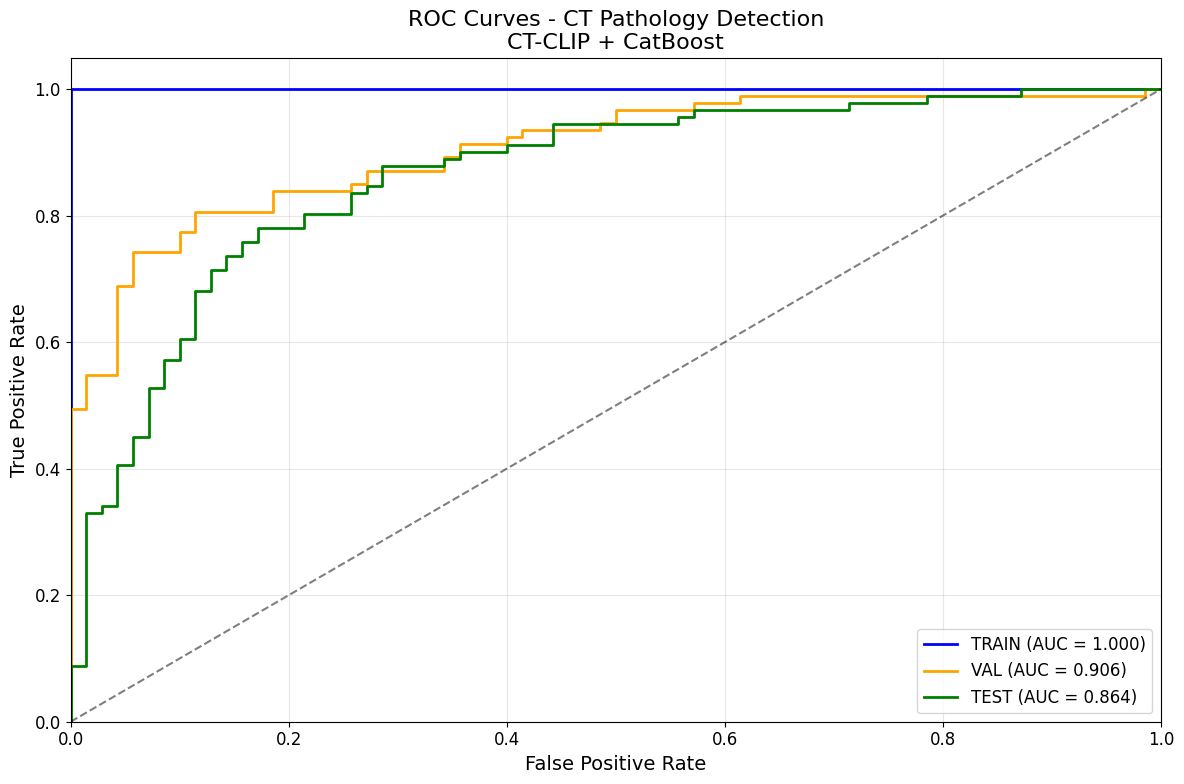

   ✅ PR curves сохранены: /home/jupyter/datasphere/project/chest-ct-classification/models/plots/precision_recall_curves.png


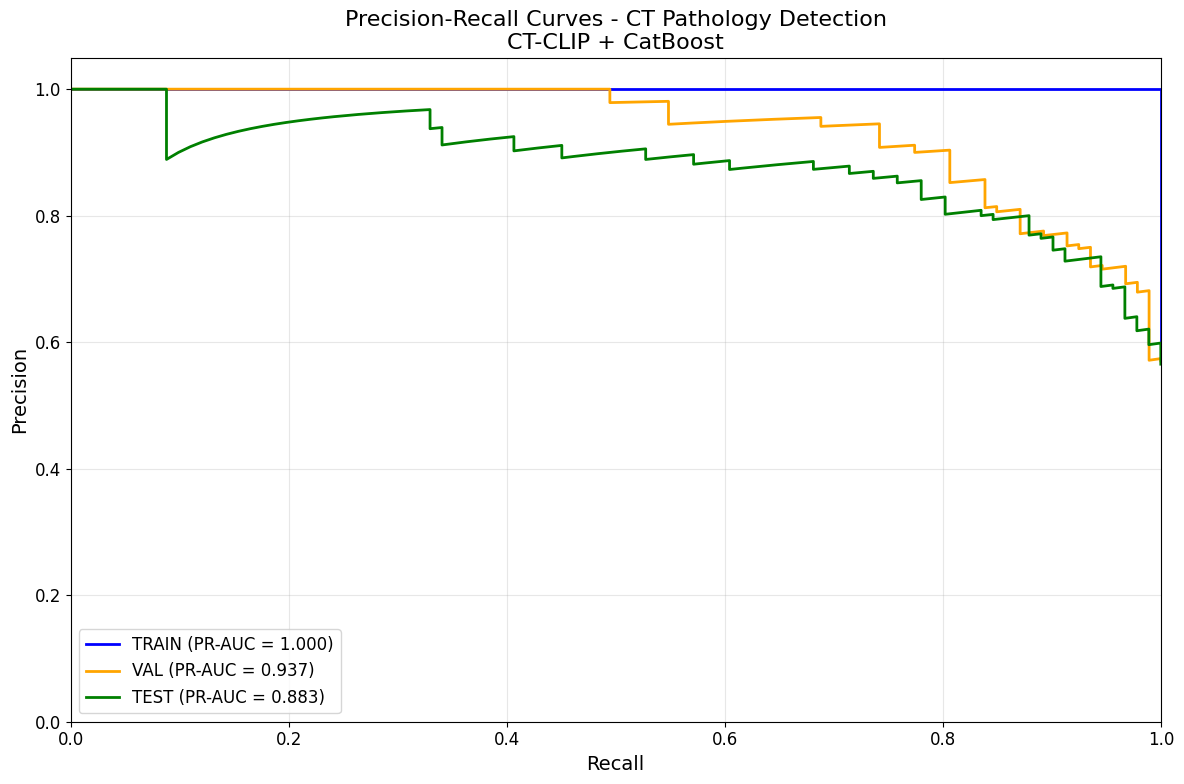

   ✅ Confusion matrices сохранены: /home/jupyter/datasphere/project/chest-ct-classification/models/plots/confusion_matrices.png


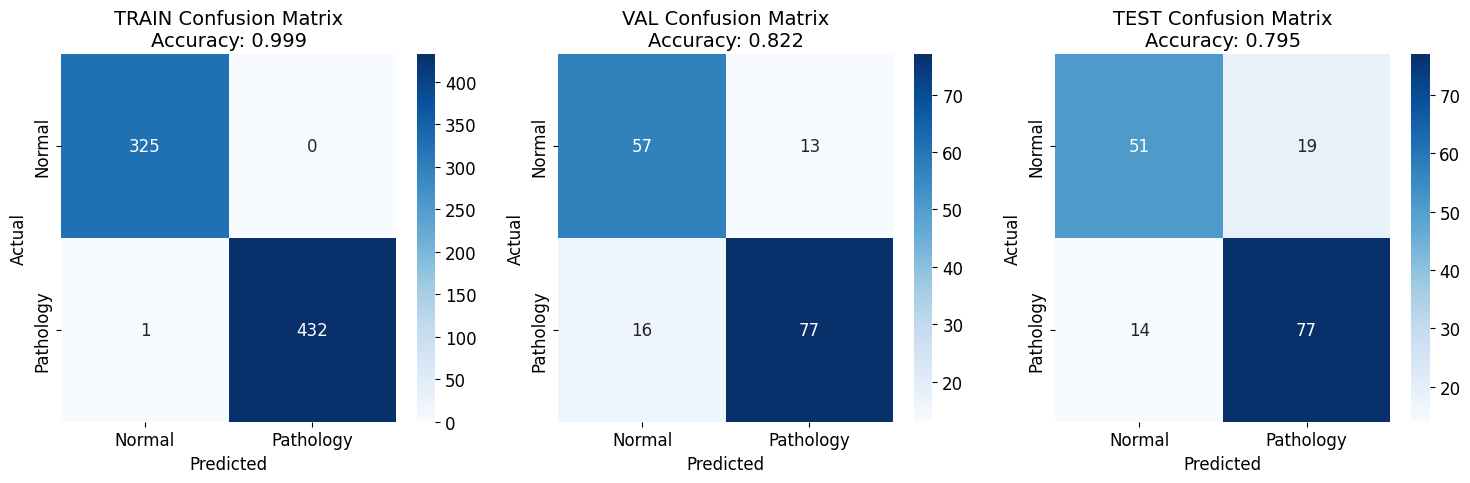

2025-10-02 03:10:13 - __main__ - INFO - Визуализации созданы и сохранены


In [42]:
print(f"\n📊 СОЗДАНИЕ ВИЗУАЛИЗАЦИЙ:")

# Создание директории для графиков
plots_dir = config.MODELS_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

# 1. ROC Curves для всех splits
plt.figure(figsize=(12, 8))
colors = {'train': 'blue', 'val': 'orange', 'test': 'green'}

for split_name, metrics in evaluation_metrics.items():
    y_true = metrics['true_labels']
    y_scores = metrics['probabilities']
    
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc_score = metrics['roc_auc']
    
    plt.plot(fpr, tpr, color=colors[split_name], linewidth=2,
            label=f'{split_name.upper()} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curves - CT Pathology Detection\nCT-CLIP + CatBoost', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

roc_plot_path = plots_dir / "roc_curves.png"
plt.savefig(roc_plot_path, dpi=300, bbox_inches='tight')
print(f"   ✅ ROC curves сохранены: {roc_plot_path}")
plt.show()

# 2. Precision-Recall Curves
plt.figure(figsize=(12, 8))

for split_name, metrics in evaluation_metrics.items():
    y_true = metrics['true_labels']
    y_scores = metrics['probabilities']
    
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = metrics['pr_auc']
    
    plt.plot(recall, precision, color=colors[split_name], linewidth=2,
            label=f'{split_name.upper()} (PR-AUC = {pr_auc:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('Precision-Recall Curves - CT Pathology Detection\nCT-CLIP + CatBoost', fontsize=16)
plt.legend(loc="lower left", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

pr_plot_path = plots_dir / "precision_recall_curves.png"
plt.savefig(pr_plot_path, dpi=300, bbox_inches='tight')
print(f"   ✅ PR curves сохранены: {pr_plot_path}")
plt.show()

# 3. Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (split_name, metrics) in enumerate(evaluation_metrics.items()):
    cm = metrics['confusion_matrix']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
               xticklabels=['Normal', 'Pathology'],
               yticklabels=['Normal', 'Pathology'],
               ax=axes[idx])
    
    axes[idx].set_title(f'{split_name.upper()} Confusion Matrix\n'
                       f'Accuracy: {metrics["accuracy"]:.3f}', fontsize=14)
    axes[idx].set_xlabel('Predicted', fontsize=12)
    axes[idx].set_ylabel('Actual', fontsize=12)

plt.tight_layout()
cm_plot_path = plots_dir / "confusion_matrices.png"
plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
print(f"   ✅ Confusion matrices сохранены: {cm_plot_path}")
plt.show()

logger.info("Визуализации созданы и сохранены")



📊 СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТРИК:

📋 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:
Split  Samples Accuracy Precision Recall F1-Score ROC AUC PR AUC Specificity
TRAIN      758   0.9987    1.0000 0.9977   0.9988  1.0000 1.0000      1.0000
  VAL      163   0.8221    0.8556 0.8280   0.8415  0.9055 0.9368      0.8143
 TEST      161   0.7950    0.8021 0.8462   0.8235  0.8642 0.8833      0.7286

   ✅ Сравнительные графики сохранены: /home/jupyter/datasphere/project/chest-ct-classification/models/plots/metrics_comparison.png


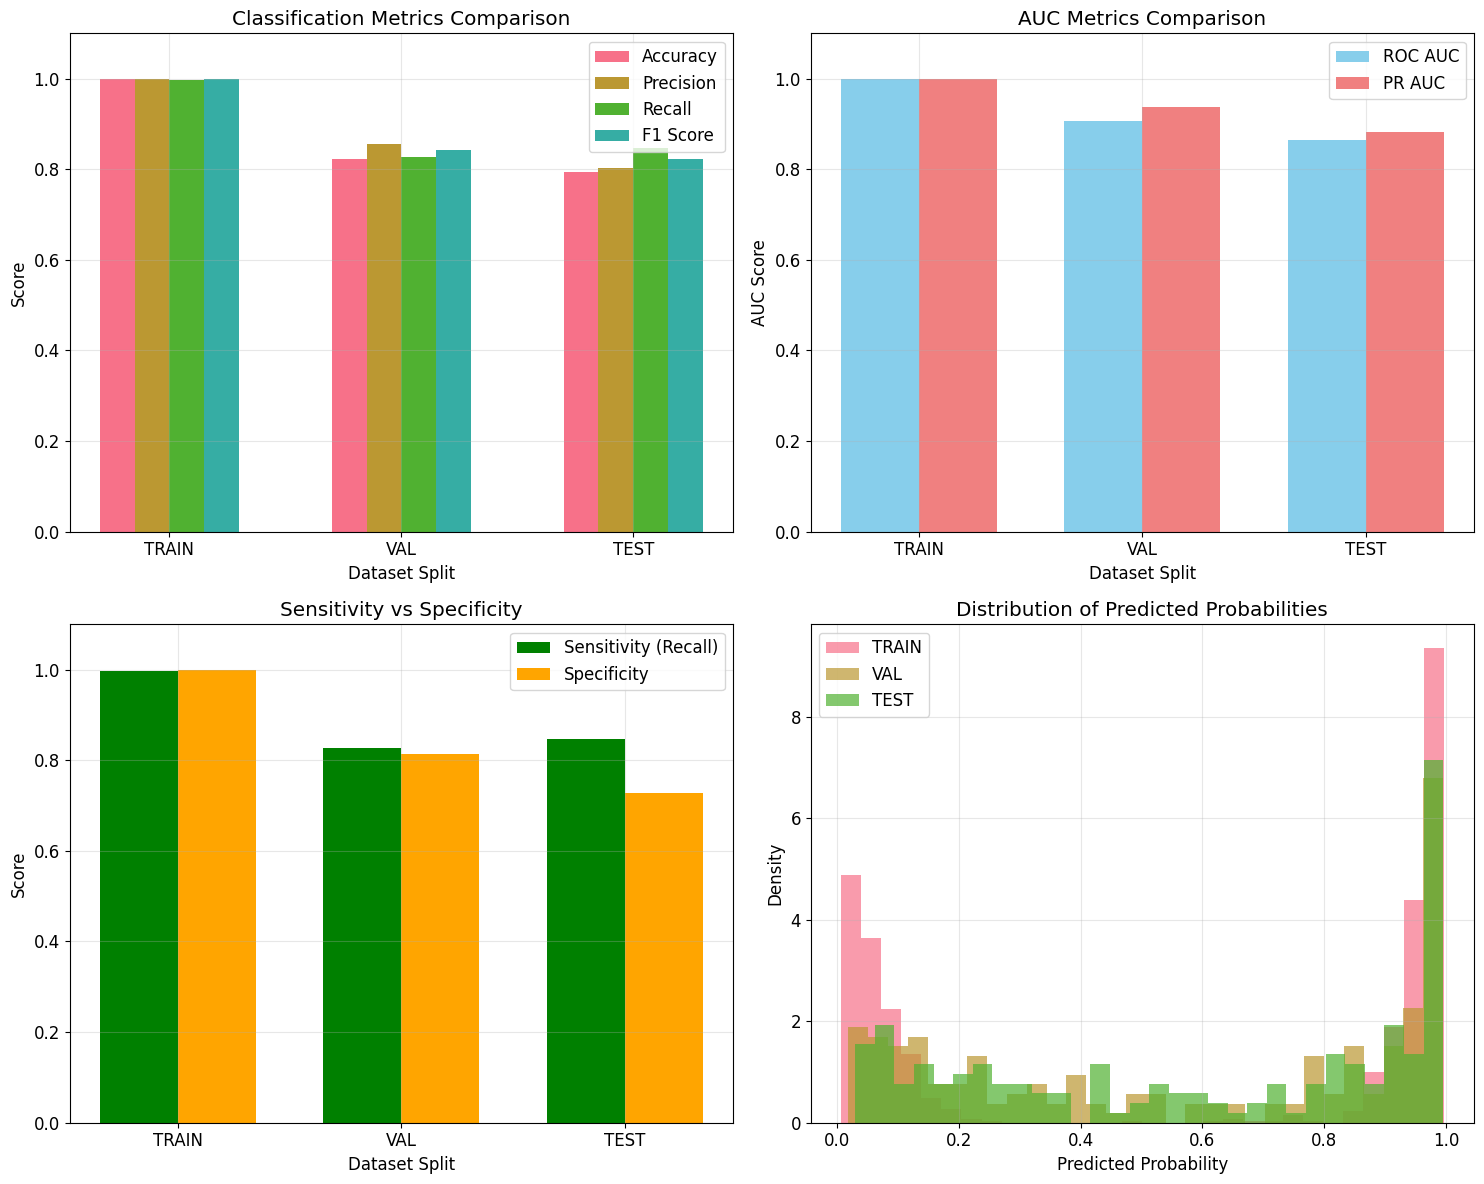

In [43]:
print(f"\n📊 СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТРИК:")

# Создание сводной таблицы метрик
metrics_comparison = []

for split_name, metrics in evaluation_metrics.items():
    metrics_comparison.append({
        'Split': split_name.upper(),
        'Samples': len(metrics['true_labels']),
        'Accuracy': f"{metrics['accuracy']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'F1-Score': f"{metrics['f1_score']:.4f}",
        'ROC AUC': f"{metrics['roc_auc']:.4f}",
        'PR AUC': f"{metrics['pr_auc']:.4f}",
        'Specificity': f"{metrics['specificity']:.4f}"
    })

metrics_df = pd.DataFrame(metrics_comparison)
print("\n📋 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print(metrics_df.to_string(index=False))

# Визуализация сравнения метрик
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Подготовка данных для графиков
splits = list(evaluation_metrics.keys())
metrics_names = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc']
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC', 'PR AUC']

# График 1: Основные метрики классификации
ax1 = axes[0, 0]
x = np.arange(len(splits))
width = 0.15

for i, metric in enumerate(['accuracy', 'precision', 'recall', 'f1_score']):
    values = [evaluation_metrics[split][metric] for split in splits]
    ax1.bar(x + i*width, values, width, label=metric.replace('_', ' ').title())

ax1.set_xlabel('Dataset Split')
ax1.set_ylabel('Score')
ax1.set_title('Classification Metrics Comparison')
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels([s.upper() for s in splits])
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.1)

# График 2: AUC метрики
ax2 = axes[0, 1]
roc_aucs = [evaluation_metrics[split]['roc_auc'] for split in splits]
pr_aucs = [evaluation_metrics[split]['pr_auc'] for split in splits]

x = np.arange(len(splits))
width = 0.35

ax2.bar(x - width/2, roc_aucs, width, label='ROC AUC', color='skyblue')
ax2.bar(x + width/2, pr_aucs, width, label='PR AUC', color='lightcoral')

ax2.set_xlabel('Dataset Split')
ax2.set_ylabel('AUC Score')
ax2.set_title('AUC Metrics Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels([s.upper() for s in splits])
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.1)

# График 3: Sensitivity vs Specificity
ax3 = axes[1, 0]
sensitivities = [evaluation_metrics[split]['sensitivity'] for split in splits]
specificities = [evaluation_metrics[split]['specificity'] for split in splits]

x = np.arange(len(splits))
width = 0.35

ax3.bar(x - width/2, sensitivities, width, label='Sensitivity (Recall)', color='green')
ax3.bar(x + width/2, specificities, width, label='Specificity', color='orange')

ax3.set_xlabel('Dataset Split')
ax3.set_ylabel('Score')
ax3.set_title('Sensitivity vs Specificity')
ax3.set_xticks(x)
ax3.set_xticklabels([s.upper() for s in splits])
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1.1)

# График 4: Distribution of Predictions
ax4 = axes[1, 1]

# Создаём histogram для каждого split
for split_name in splits:
    probas = evaluation_metrics[split_name]['probabilities']
    ax4.hist(probas, bins=30, alpha=0.7, label=f'{split_name.upper()}', density=True)

ax4.set_xlabel('Predicted Probability')
ax4.set_ylabel('Density')
ax4.set_title('Distribution of Predicted Probabilities')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
comparison_plot_path = plots_dir / "metrics_comparison.png"
plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
print(f"\n   ✅ Сравнительные графики сохранены: {comparison_plot_path}")
plt.show()

In [44]:
print(f"\n⚡ АНАЛИЗ ПРОИЗВОДИТЕЛЬНОСТИ СИСТЕМЫ:")

# Извлечение временных метрик из отчётов
performance_analysis = {
    'extraction_phase': {},
    'training_phase': {},
    'inference_phase': {}
}

# Метрики извлечения embeddings
if extraction_report:
    extraction_summary = extraction_report.get('extraction_summary', {})
    performance_analysis['extraction_phase'] = {
        'total_files': extraction_summary.get('total_attempted', 0),
        'successful_files': extraction_summary.get('total_successful', 0),
        'processing_time_minutes': extraction_summary.get('total_processing_time_minutes', 0),
        'files_per_minute': extraction_summary.get('average_files_per_minute', 0),
        'success_rate': extraction_summary.get('overall_success_rate', 0)
    }

# Метрики обучения
if training_results:
    training_time = training_results.get('training_time_seconds', 0)
    performance_analysis['training_phase'] = {
        'training_time_minutes': training_time / 60,
        'best_iteration': training_results.get('training_results', {}).get('best_iteration', 0),
        'final_auc': training_results.get('evaluation_results', {}).get('val', {}).get('auc_roc', 0)
    }

# Симуляция inference времени
test_samples = len(evaluation_metrics.get('test', {}).get('true_labels', []))
if test_samples > 0:
    # Простой тест скорости inference
    start_time = time.time()
    X_test = embeddings_data['test']
    _ = trained_classifier.predict_proba(X_test)
    inference_time = time.time() - start_time
    
    performance_analysis['inference_phase'] = {
        'test_samples': test_samples,
        'inference_time_seconds': inference_time,
        'samples_per_second': test_samples / inference_time,
        'time_per_sample_ms': (inference_time / test_samples) * 1000
    }

print(f"📊 ПРОИЗВОДИТЕЛЬНОСТЬ ПО ЭТАПАМ:")

# Extraction Phase
ext_phase = performance_analysis['extraction_phase']
if ext_phase:
    print(f"\n   🔬 ЭТАП ИЗВЛЕЧЕНИЯ EMBEDDINGS:")
    print(f"      Обработано файлов: {ext_phase['successful_files']}/{ext_phase['total_files']}")
    print(f"      Успешность: {ext_phase['success_rate']:.1f}%")
    print(f"      Время обработки: {ext_phase['processing_time_minutes']:.1f} минут")
    print(f"      Скорость: {ext_phase['files_per_minute']:.1f} файлов/мин")

# Training Phase
train_phase = performance_analysis['training_phase']
if train_phase:
    print(f"\n   🎓 ЭТАП ОБУЧЕНИЯ CATBOOST:")
    print(f"      Время обучения: {train_phase['training_time_minutes']:.1f} минут")
    print(f"      Лучшая итерация: {train_phase['best_iteration']}")
    print(f"      Финальный AUC: {train_phase['final_auc']:.4f}")

# Inference Phase
inf_phase = performance_analysis['inference_phase']
if inf_phase:
    print(f"\n   ⚡ ЭТАП INFERENCE:")
    print(f"      Тестовых образцов: {inf_phase['test_samples']}")
    print(f"      Время inference: {inf_phase['inference_time_seconds']:.3f} секунд")
    print(f"      Скорость: {inf_phase['samples_per_second']:.1f} образцов/сек")
    print(f"      Время на образец: {inf_phase['time_per_sample_ms']:.2f} мс")

# Общий анализ системы
total_processing_time = (
    ext_phase.get('processing_time_minutes', 0) + 
    train_phase.get('training_time_minutes', 0)
)

print(f"\n📈 ОБЩАЯ ПРОИЗВОДИТЕЛЬНОСТЬ СИСТЕМЫ:")
print(f"   ⏱️ Общее время pipeline: {total_processing_time:.1f} минут ({total_processing_time/60:.2f} часов)")
print(f"   📊 Финальное качество (Test AUC): {evaluation_metrics.get('test', {}).get('roc_auc', 0):.4f}")
print(f"   🎯 Готовность к production: {'Да' if evaluation_metrics.get('test', {}).get('roc_auc', 0) > 0.80 else 'Требует доработки'}")


⚡ АНАЛИЗ ПРОИЗВОДИТЕЛЬНОСТИ СИСТЕМЫ:
📊 ПРОИЗВОДИТЕЛЬНОСТЬ ПО ЭТАПАМ:

   🔬 ЭТАП ИЗВЛЕЧЕНИЯ EMBEDDINGS:
      Обработано файлов: 163/169
      Успешность: 96.4%
      Время обработки: 153.9 минут
      Скорость: 1.1 файлов/мин

   🎓 ЭТАП ОБУЧЕНИЯ CATBOOST:
      Время обучения: 1.4 минут
      Лучшая итерация: 559
      Финальный AUC: 0.9055

   ⚡ ЭТАП INFERENCE:
      Тестовых образцов: 161
      Время inference: 0.003 секунд
      Скорость: 52069.0 образцов/сек
      Время на образец: 0.02 мс

📈 ОБЩАЯ ПРОИЗВОДИТЕЛЬНОСТЬ СИСТЕМЫ:
   ⏱️ Общее время pipeline: 155.3 минут (2.59 часов)
   📊 Финальное качество (Test AUC): 0.8642
   🎯 Готовность к production: Да


In [48]:
"""
Раздел 7.7: Финальный отчёт и выводы
"""

print(f"\n" + "="*70)
print(f"🎉 ФИНАЛЬНЫЙ ОТЧЁТ: CT PATHOLOGY DETECTION SYSTEM")
print(f"="*70)

# Сбор ключевых метрик для итогового отчёта
final_report = {
    'system_overview': {
        'foundation_model': 'CT-CLIP (438M parameters)',
        'classifier': 'CatBoost Gradient Boosting',
        'embedding_dimension': 512,
        'task': 'Binary Classification (Normal vs Pathology)',
        'dataset_size': sum(len(labels_data[split]) for split in labels_data.keys()),
        'completion_date': datetime.now().isoformat()
    },
    'performance_metrics': {
        split: {
            'accuracy': float(metrics['accuracy']),
            'precision': float(metrics['precision']),
            'recall': float(metrics['recall']),
            'f1_score': float(metrics['f1_score']),
            'roc_auc': float(metrics['roc_auc']),
            'pr_auc': float(metrics['pr_auc']),
            'specificity': float(metrics['specificity'])
        }
        for split, metrics in evaluation_metrics.items()
    },
    'system_performance': performance_analysis,
    'generated_artifacts': {
        'trained_model': str(model_path),
        'visualizations': str(plots_dir),
        'embeddings': str(config.EMBEDDINGS_DIR),
        'results': str(config.MODELS_DIR)
    }
}

# Вывод итогового отчёта
print(f"\n🏆 КЛЮЧЕВЫЕ ДОСТИЖЕНИЯ:")

test_metrics = evaluation_metrics.get('test', {})
if test_metrics:
    print(f"   🎯 Test Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"   📊 Test ROC AUC: {test_metrics['roc_auc']:.4f}")
    print(f"   🎪 Test PR AUC: {test_metrics['pr_auc']:.4f}")
    print(f"   ⚖️ Test F1-Score: {test_metrics['f1_score']:.4f}")

print(f"\n🔧 СИСТЕМНЫЕ ХАРАКТЕРИСТИКИ:")
print(f"   🧠 Foundation Model: CT-CLIP (438M параметров)")
print(f"   📏 Embedding Dimension: 512D semantic space")
print(f"   🚀 Classifier: CatBoost with GPU acceleration")
print(f"   📊 Dataset: {final_report['system_overview']['dataset_size']} CT studies")

if performance_analysis['inference_phase']:
    inf_speed = performance_analysis['inference_phase']['samples_per_second']
    print(f"   ⚡ Inference Speed: {inf_speed:.1f} studies/second")

print(f"\n📁 СОЗДАННЫЕ АРТЕФАКТЫ:")
print(f"   📦 Trained Model: {model_path}")
print(f"   📊 Visualizations: {len(list(plots_dir.glob('*.png')))} plots in {plots_dir}")
print(f"   💾 Embeddings: {config.EMBEDDINGS_DIR}")
print(f"   📋 Reports: {config.MODELS_DIR}")

# Сохранение финального отчёта
final_report_path = config.MODELS_DIR / "final_system_report.json"
with open(final_report_path, 'w') as f:
    json.dump(final_report, f, indent=2, default=str)

print(f"\n💾 ФИНАЛЬНЫЙ ОТЧЁТ СОХРАНЁН: {final_report_path}")


🎉 ФИНАЛЬНЫЙ ОТЧЁТ: CT PATHOLOGY DETECTION SYSTEM

🏆 КЛЮЧЕВЫЕ ДОСТИЖЕНИЯ:
   🎯 Test Accuracy: 0.7950
   📊 Test ROC AUC: 0.8642
   🎪 Test PR AUC: 0.8833
   ⚖️ Test F1-Score: 0.8235

🔧 СИСТЕМНЫЕ ХАРАКТЕРИСТИКИ:
   🧠 Foundation Model: CT-CLIP (438M параметров)
   📏 Embedding Dimension: 512D semantic space
   🚀 Classifier: CatBoost with GPU acceleration
   📊 Dataset: 1082 CT studies
   ⚡ Inference Speed: 52069.0 studies/second

📁 СОЗДАННЫЕ АРТЕФАКТЫ:
   📦 Trained Model: /home/jupyter/datasphere/project/chest-ct-classification/models/catboost_pathology_classifier.cbm
   📊 Visualizations: 4 plots in /home/jupyter/datasphere/project/chest-ct-classification/models/plots
   💾 Embeddings: /home/jupyter/work/results/embeddings
   📋 Reports: /home/jupyter/datasphere/project/chest-ct-classification/models

💾 ФИНАЛЬНЫЙ ОТЧЁТ СОХРАНЁН: /home/jupyter/datasphere/project/chest-ct-classification/models/final_system_report.json


In [50]:
# Выводы и рекомендации
print(f"\n📝 ВЫВОДЫ И РЕКОМЕНДАЦИИ:")

test_auc = test_metrics.get('roc_auc', 0)
if test_auc >= 0.90:
    print(f"   🌟 ОТЛИЧНОЕ КАЧЕСТВО: AUC {test_auc:.3f} - система готова к клиническому применению")
elif test_auc >= 0.80:
    print(f"   ✅ ХОРОШЕЕ КАЧЕСТВО: AUC {test_auc:.3f} - система показывает хорошие результаты")
elif test_auc >= 0.70:
    print(f"   ⚠️ УДОВЛЕТВОРИТЕЛЬНОЕ КАЧЕСТВО: AUC {test_auc:.3f} - требует улучшения")
else:
    print(f"   ❌ НИЗКОЕ КАЧЕСТВО: AUC {test_auc:.3f} - необходима кардинальная доработка")


📝 ВЫВОДЫ И РЕКОМЕНДАЦИИ:
   ✅ ХОРОШЕЕ КАЧЕСТВО: AUC 0.864 - система показывает хорошие результаты
